# Trabalho Prático — Notebook


## Trabalho Aprendizado de Máquina

#### Bibliotecas

In [1]:
#%pip install torch torchvision

In [2]:
import copy, math, random, os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset, TensorDataset


SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

os.makedirs('figuras', exist_ok=True)

def save_fig(filename):
    plt.savefig(f'figuras/{filename}', dpi=150, bbox_inches='tight')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cpu


## Definições Comuns

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = [nn.Flatten()]
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class CNN(nn.Module):
    """CNN padronizada para imagens: 2 blocos Conv+ReLU+MaxPool, 1 camada FC oculta."""
    def __init__(self, in_channels, img_size, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        feat_size = (img_size // 4) ** 2 * 64
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_size, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [4]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.1, **kwargs):
        assert rho >= 0.0
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        return torch.norm(torch.stack([
            p.grad.norm(p=2)
            for group in self.param_groups for p in group['params']
            if p.grad is not None
        ]), p=2)

In [5]:
def train_model(model, train_loader, val_loader, optimizer, epochs,
                is_sam=False, patience=30, restore_best=True):
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        t_loss = t_correct = t_total = 0
        for X, y in train_loader:
            if is_sam:
                out = model(X); loss = criterion(out, y); loss.backward()
                optimizer.first_step(zero_grad=True)
                out2 = model(X); criterion(out2, y).backward()
                optimizer.second_step(zero_grad=True)
                with torch.no_grad():
                    out_log = model(X); loss_log = criterion(out_log, y)
            else:
                optimizer.zero_grad()
                out_log = model(X); loss_log = criterion(out_log, y)
                loss_log.backward(); optimizer.step()
            t_loss += loss_log.item()
            t_correct += ((out_log > 0.0).float() == y).sum().item()
            t_total += y.size(0)

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for X, y in val_loader:
                out = model(X); loss = criterion(out, y)
                v_loss += loss.item()
                v_correct += ((out > 0.0).float() == y).sum().item()
                v_total += y.size(0)

        avg_v = v_loss / len(val_loader)
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(avg_v)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

        if avg_v < best_val_loss:
            best_val_loss = avg_v
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                break

    if restore_best:
        model.load_state_dict(best_state)
    history['epochs_trained'] = len(history['train_loss'])
    history['best_val_loss'] = best_val_loss
    return history

In [6]:
def train_model_multiclass(model, train_loader, val_loader, optimizer, epochs,
                            is_sam=False, patience=30, restore_best=True):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        t_loss = t_correct = t_total = 0
        for X, y in train_loader:
            if is_sam:
                out = model(X); loss = criterion(out, y); loss.backward()
                optimizer.first_step(zero_grad=True)
                out2 = model(X); criterion(out2, y).backward()
                optimizer.second_step(zero_grad=True)
                with torch.no_grad():
                    out_log = model(X); loss_log = criterion(out_log, y)
            else:
                optimizer.zero_grad()
                out_log = model(X); loss_log = criterion(out_log, y)
                loss_log.backward(); optimizer.step()
            t_loss += loss_log.item()
            t_correct += (out_log.argmax(1) == y).sum().item()
            t_total += y.size(0)

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for X, y in val_loader:
                out = model(X); loss = criterion(out, y)
                v_loss += loss.item()
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += y.size(0)

        avg_v = v_loss / len(val_loader)
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(avg_v)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

        if avg_v < best_val_loss:
            best_val_loss = avg_v
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                break

    if restore_best:
        model.load_state_dict(best_state)
    history['epochs_trained'] = len(history['train_loss'])
    history['best_val_loss'] = best_val_loss
    return history

In [7]:
def evaluate_binary(model, loader):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            out = model(X)
            total_loss += criterion(out, y).item()
            correct += ((out > 0.0).float() == y).sum().item()
            total += y.size(0)
    return {'loss': total_loss / len(loader), 'accuracy': correct / total}


def evaluate_multiclass(model, loader):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            out = model(X)
            total_loss += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return {'loss': total_loss / len(loader), 'accuracy': correct / total}


def resumir_resultados(nome, model, tr_loader, val_loader, te_loader, is_binary=True):
    ev = evaluate_binary if is_binary else evaluate_multiclass
    tm = ev(model, tr_loader)
    vm = ev(model, val_loader)
    sm = ev(model, te_loader)
    gap = tm['accuracy'] - sm['accuracy']
    print(f'{nome}')
    print(f"  treino: loss={tm['loss']:.4f}  acc={tm['accuracy']:.3f}")
    print(f"  val:    loss={vm['loss']:.4f}  acc={vm['accuracy']:.3f}")
    print(f"  teste:  loss={sm['loss']:.4f}  acc={sm['accuracy']:.3f}")
    print(f'  gap (treino-teste acc): {gap:.3f}')
    return {'train': tm, 'val': vm, 'test': sm, 'gap': gap}


# alias de compatibilidade com células de análise adicional
evaluate_model = evaluate_binary

In [8]:
CORES = {'Adam': '#3A37DD', 'SGD': '#2ca02c', 'SAM': '#D85A30'}


def plot_comparacao(historicos, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, h in historicos.items():
        cor = CORES.get(label, 'gray')
        ep = range(1, len(h['train_loss']) + 1)
        axes[0].plot(ep, h['train_loss'], color=cor, label=f'{label} treino')
        axes[0].plot(ep, h['val_loss'],   color=cor, ls='--', alpha=0.6, label=f'{label} val')
        axes[1].plot(ep, h['train_acc'],  color=cor, label=f'{label} treino')
        axes[1].plot(ep, h['val_acc'],    color=cor, ls='--', alpha=0.6, label=f'{label} val')
    for ax, ylabel in zip(axes, ['loss', 'acurácia']):
        ax.set_xlabel('época'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7); ax.grid(True, alpha=.3)
    fig.suptitle(title); fig.tight_layout(); plt.show()


def plot_metricas_barras(resultados, title=''):
    labels = list(resultados.keys())
    tr_acc = [resultados[l]['train']['accuracy'] for l in labels]
    te_acc = [resultados[l]['test']['accuracy']  for l in labels]
    gaps   = [resultados[l]['gap']               for l in labels]
    x, w = np.arange(len(labels)), 0.3
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(x - w/2, tr_acc, w, label='treino', color='#3A37DD')
    axes[0].bar(x + w/2, te_acc, w, label='teste',  color='#D85A30')
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('acurácia')
    axes[0].legend(); axes[0].set_title('Acurácia treino vs. teste')
    cores_gap = [CORES.get(l, 'gray') for l in labels]
    axes[1].bar(x, gaps, color=cores_gap)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('gap (treino − teste)'); axes[1].set_title('Gap de Generalização')
    axes[1].grid(True, alpha=.3, axis='y')
    fig.suptitle(title); fig.tight_layout(); plt.show()


def plot_lambda_bar(lambdas, title=''):
    labels = list(lambdas.keys())
    values = [lambdas[l] for l in labels]
    cores = [CORES.get(l, 'gray') for l in labels]
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=cores)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 val + max(values)*0.015, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=10)
    plt.ylabel(r'$\lambda_{\max}(H)$'); plt.title(title)
    plt.grid(True, alpha=.3, axis='y'); plt.tight_layout(); plt.show()


def plot_history(history, title=''):
    plot_comparacao({'modelo': history}, title=title)

In [9]:
def calcular_autovalor_dominante_full(inputs, targets, model, criterion,
                                      num_iterations=20, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)
    num_params = sum(p.numel() for p in model.parameters())
    v = torch.randn(num_params, device=inputs.device)
    v = v / torch.norm(v)
    history_eigenvalues = []
    for _ in range(num_iterations):
        model.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
        flat_grads = torch.cat([g.contiguous().view(-1) for g in grads])
        grad_v_prod = torch.dot(flat_grads, v)
        hvp = torch.autograd.grad(grad_v_prod, model.parameters())
        flat_hvp = torch.cat([h.contiguous().view(-1) for h in hvp])
        eigenvalue = torch.dot(v, flat_hvp).item()
        history_eigenvalues.append(eigenvalue)
        hvp_norm = torch.norm(flat_hvp)
        if hvp_norm.item() < 1e-12:
            break
        v = flat_hvp / hvp_norm
    return history_eigenvalues, v.detach()


def get_lambda_max(model, inputs, targets, criterion, num_iterations=20, seed=None):
    history, _ = calcular_autovalor_dominante_full(
        inputs, targets, model, criterion,
        num_iterations=num_iterations, seed=seed)
    return history[-1]

## Dataset 1: Titanic (Classificação Binária)

**Tarefa:** prever sobrevivência (binário). **Critério:** BCEWithLogitsLoss.

### Pré-processamento

In [10]:
df_titanic = pd.read_csv('dados/Titanic/Titanic-Dataset.csv')
df_titanic_model = df_titanic.drop(columns=['PassengerId','Name','Ticket','Cabin']).copy()

X = df_titanic_model.drop(columns=['Survived'])
y = df_titanic_model['Survived'].astype(float)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

categorical_cols = ['Sex', 'Embarked']
age_median = X_train_raw['Age'].median()
fare_median = X_train_raw['Fare'].median()
embarked_mode = X_train_raw['Embarked'].mode()[0]

def preprocess_titanic_split(split):
    split = split.copy()
    split['Age'] = split['Age'].fillna(age_median)
    split['Fare'] = split['Fare'].fillna(fare_median)
    split['Embarked'] = split['Embarked'].fillna(embarked_mode)
    split = pd.get_dummies(split, columns=categorical_cols, drop_first=True)
    return split.astype(float)

X_train_pre = preprocess_titanic_split(X_train_raw)
X_val_pre   = preprocess_titanic_split(X_val_raw).reindex(columns=X_train_pre.columns, fill_value=0.0)
X_test_pre  = preprocess_titanic_split(X_test_raw).reindex(columns=X_train_pre.columns, fill_value=0.0)

scaler_tit = StandardScaler()
X_train_scaled = scaler_tit.fit_transform(X_train_pre)
X_val_scaled   = scaler_tit.transform(X_val_pre)
X_test_scaled  = scaler_tit.transform(X_test_pre)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

BATCH_TIT = 32
train_loader_tit = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_TIT, shuffle=True)
val_loader_tit   = DataLoader(TensorDataset(X_val_tensor,   y_val_tensor),   batch_size=BATCH_TIT, shuffle=False)
test_loader_tit  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=BATCH_TIT, shuffle=False)

input_dim_tit = X_train_tensor.shape[1]
print(f'Features: {list(X_train_pre.columns)}')
print(f'input_dim={input_dim_tit}  train={len(y_train)}  val={len(y_val)}  test={len(y_test)}')

Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
input_dim=8  train=534  val=178  test=179


### Treinamento: Adam, SGD e SAM

In [11]:
EPOCAS_TIT, PATIENCE_TIT = 300, 40
criterion_tit = nn.BCEWithLogitsLoss()

# Adam
set_seed(SEED)
modelo_adam_tit = MLP(input_dim_tit, [64, 32], 1)
hist_adam_tit = train_model(
    modelo_adam_tit, train_loader_tit, val_loader_tit,
    optim.Adam(modelo_adam_tit.parameters(), lr=0.01, weight_decay=1e-4),
    EPOCAS_TIT, patience=PATIENCE_TIT)
print(f'Adam  → {hist_adam_tit["epochs_trained"]} épocas')

# SGD
set_seed(SEED)
modelo_sgd_tit = MLP(input_dim_tit, [64, 32], 1)
hist_sgd_tit = train_model(
    modelo_sgd_tit, train_loader_tit, val_loader_tit,
    optim.SGD(modelo_sgd_tit.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    EPOCAS_TIT, patience=PATIENCE_TIT)
print(f'SGD   → {hist_sgd_tit["epochs_trained"]} épocas')

# SAM + Adam
set_seed(SEED)
modelo_sam_tit = MLP(input_dim_tit, [64, 32], 1)
hist_sam_tit = train_model(
    modelo_sam_tit, train_loader_tit, val_loader_tit,
    SAM(modelo_sam_tit.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    EPOCAS_TIT, is_sam=True, patience=PATIENCE_TIT)
print(f'SAM   → {hist_sam_tit["epochs_trained"]} épocas')

historicos_tit = {'Adam': hist_adam_tit, 'SGD': hist_sgd_tit, 'SAM': hist_sam_tit}

Adam  → 44 épocas
SGD   → 58 épocas
SAM   → 44 épocas


### Curvas de Aprendizado

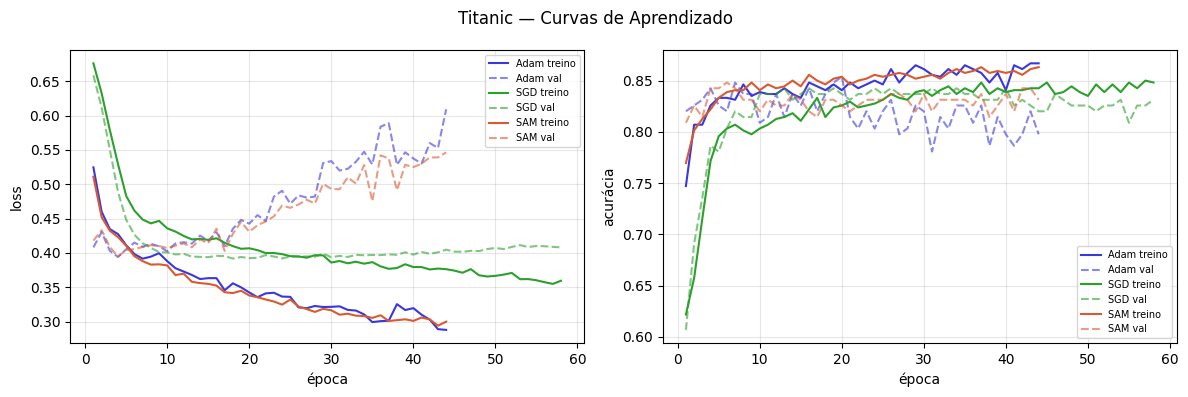

In [12]:
plot_comparacao(historicos_tit, title='Titanic — Curvas de Aprendizado')

### Métricas Finais e Gap de Generalização

Adam
  treino: loss=0.3969  acc=0.831
  val:    loss=0.3941  acc=0.843
  teste:  loss=0.4372  acc=0.816
  gap (treino-teste acc): 0.016
SGD
  treino: loss=0.4084  acc=0.824
  val:    loss=0.3917  acc=0.837
  teste:  loss=0.4411  acc=0.821
  gap (treino-teste acc): 0.003
SAM
  treino: loss=0.4022  acc=0.826
  val:    loss=0.3947  acc=0.843
  teste:  loss=0.4339  acc=0.821
  gap (treino-teste acc): 0.005


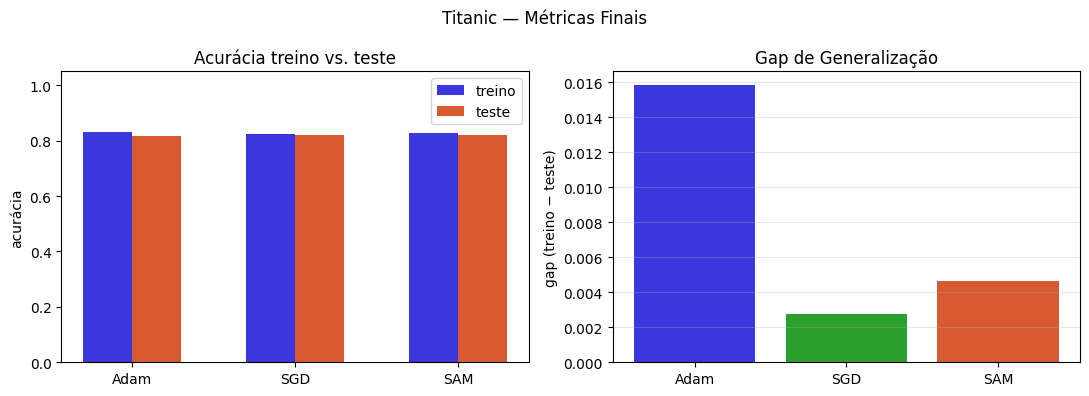

In [13]:
resultados_tit = {}
for nome, modelo in [('Adam', modelo_adam_tit), ('SGD', modelo_sgd_tit), ('SAM', modelo_sam_tit)]:
    resultados_tit[nome] = resumir_resultados(
        nome, modelo, train_loader_tit, val_loader_tit, test_loader_tit, is_binary=True)

plot_metricas_barras(resultados_tit, title='Titanic — Métricas Finais')

### Sharpness (λ_max da Hessiana)

Adam: λ_max = 1.2745
SGD: λ_max = 2.1769
SAM: λ_max = 0.8818


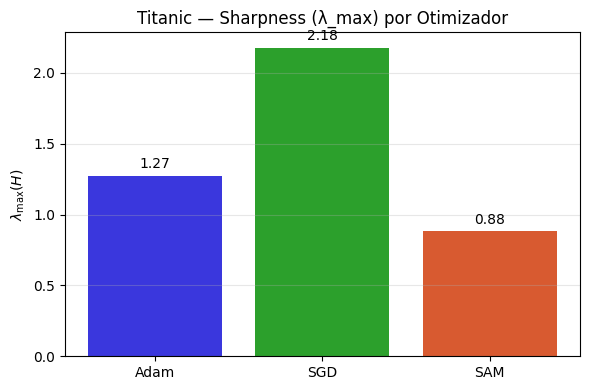

In [14]:
lambdas_tit = {}
for nome, modelo in [('Adam', modelo_adam_tit), ('SGD', modelo_sgd_tit), ('SAM', modelo_sam_tit)]:
    lam = get_lambda_max(modelo, X_train_tensor, y_train_tensor, criterion_tit,
                         num_iterations=30, seed=SEED)
    lambdas_tit[nome] = lam
    print(f'{nome}: λ_max = {lam:.4f}')

plot_lambda_bar(lambdas_tit, title='Titanic — Sharpness (λ_max) por Otimizador')

## Análise Adicional SAM — Ablação de ρ (Titanic)

Treina 5 seeds × 6 valores de ρ. Registra λ_max e gap de generalização para cada configuração.

In [15]:
SEEDS_EXPERIMENTO = [0, 1, 2, 3, 4]
RHO_VALUES = [None, 0.001, 0.01, 0.05, 0.1, 0.5]
BASE_HIDDEN_DIMS = [64, 32]
BASE_LR = 0.001
BASE_WEIGHT_DECAY = 1e-4
BASE_EPOCHS = 300
BASE_PATIENCE = 40

def format_rho_label(rho):
    return 'Adam' if rho is None else f'SAM rho={rho:g}'

configuracoes_rho = [
    {'nome': format_rho_label(rho), 'rho': rho, 'is_sam': rho is not None}
    for rho in RHO_VALUES
]

In [16]:
resultados_rho = []
modelos_representativos = {}

for seed in SEEDS_EXPERIMENTO:
    print(f"\n{'#'*60}\nSEED {seed}\n{'#'*60}")
    for cfg in configuracoes_rho:
        nome, rho, is_sam = cfg['nome'], cfg['rho'], cfg['is_sam']
        print(f'\n--- {nome} ---')
        set_seed(seed)
        model = MLP(input_dim_tit, BASE_HIDDEN_DIMS, 1)
        gen = torch.Generator().manual_seed(seed)
        loader_seed = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                                  batch_size=BATCH_TIT, shuffle=True, generator=gen)
        if is_sam:
            optimizer = SAM(model.parameters(), optim.Adam,
                            lr=BASE_LR, weight_decay=BASE_WEIGHT_DECAY, rho=rho)
        else:
            optimizer = optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=BASE_WEIGHT_DECAY)
        history = train_model(model, loader_seed, val_loader_tit, optimizer,
                               BASE_EPOCHS, is_sam=is_sam, patience=BASE_PATIENCE)
        tm = evaluate_binary(model, train_loader_tit)
        vm = evaluate_binary(model, val_loader_tit)
        sm = evaluate_binary(model, test_loader_tit)
        gap_loss = sm['loss'] - tm['loss']
        gap_acc  = tm['accuracy'] - sm['accuracy']
        lam = get_lambda_max(model, X_train_tensor, y_train_tensor, criterion_tit,
                              num_iterations=30, seed=seed)
        print(f"ep={history['epochs_trained']:>3} train_loss={tm['loss']:.4f} "
              f"test_loss={sm['loss']:.4f} gap={gap_loss:+.4f} λ_max={lam:.4f}")
        resultados_rho.append({
            'seed': seed, 'nome': nome, 'rho': 'Adam' if rho is None else rho,
            'is_sam': is_sam, 'epochs': history['epochs_trained'],
            'train_loss': tm['loss'], 'val_loss': vm['loss'], 'test_loss': sm['loss'],
            'train_acc': tm['accuracy'], 'val_acc': vm['accuracy'], 'test_acc': sm['accuracy'],
            'gap_loss': gap_loss, 'gap_acc': gap_acc, 'lambda_max': lam,
        })
        if seed == SEEDS_EXPERIMENTO[0]:
            modelos_representativos[nome] = copy.deepcopy(model)


############################################################
SEED 0
############################################################

--- Adam ---
ep= 61 train_loss=0.3874 test_loss=0.4137 gap=+0.0263 λ_max=1.9754

--- SAM rho=0.001 ---
ep= 61 train_loss=0.3876 test_loss=0.4143 gap=+0.0268 λ_max=1.9646

--- SAM rho=0.01 ---
ep= 61 train_loss=0.3882 test_loss=0.4141 gap=+0.0259 λ_max=1.8857

--- SAM rho=0.05 ---
ep= 61 train_loss=0.3902 test_loss=0.4152 gap=+0.0249 λ_max=1.6052

--- SAM rho=0.1 ---
ep= 59 train_loss=0.4020 test_loss=0.4195 gap=+0.0175 λ_max=1.2806

--- SAM rho=0.5 ---
ep= 86 train_loss=0.3888 test_loss=0.4251 gap=+0.0363 λ_max=0.5639

############################################################
SEED 1
############################################################

--- Adam ---
ep= 55 train_loss=0.3969 test_loss=0.4285 gap=+0.0316 λ_max=1.8153

--- SAM rho=0.001 ---
ep= 55 train_loss=0.3969 test_loss=0.4284 gap=+0.0315 λ_max=1.8018

--- SAM rho=0.01 ---
ep= 54 train_loss=0.39

In [17]:
df_rho = pd.DataFrame(resultados_rho)

summary_rho = (
    df_rho.groupby('nome', sort=False)
    .agg(lambda_mean=('lambda_max','mean'), lambda_std=('lambda_max','std'),
         gap_loss_mean=('gap_loss','mean'), gap_loss_std=('gap_loss','std'),
         test_acc_mean=('test_acc','mean'), test_acc_std=('test_acc','std'),
         epochs_mean=('epochs','mean'))
    .reset_index()
)

print('Mean +/- std por configuração:')
for _, row in summary_rho.iterrows():
    print(f"{row['nome']:<14} "
          f"λ={row['lambda_mean']:.4f}±{row['lambda_std']:.4f} "
          f"gap={row['gap_loss_mean']:+.4f}±{row['gap_loss_std']:.4f} "
          f"test_acc={row['test_acc_mean']:.3f}±{row['test_acc_std']:.3f}")

Mean +/- std por configuração:
Adam           λ=2.0563±0.2319 gap=+0.0329±0.0043 test_acc=0.822±0.005
SAM rho=0.001  λ=2.0608±0.2508 gap=+0.0354±0.0072 test_acc=0.825±0.008
SAM rho=0.01   λ=1.9567±0.2039 gap=+0.0364±0.0152 test_acc=0.827±0.006
SAM rho=0.05   λ=1.6034±0.0833 gap=+0.0359±0.0129 test_acc=0.826±0.005
SAM rho=0.1    λ=1.3026±0.0643 gap=+0.0311±0.0132 test_acc=0.826±0.006
SAM rho=0.5    λ=0.5308±0.0593 gap=+0.0537±0.0122 test_acc=0.828±0.013


/tmp/ipykernel_217943/191803417.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(lambda_data, labels=labels, showmeans=True)
/tmp/ipykernel_217943/191803417.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(gap_data, labels=labels, showmeans=True)


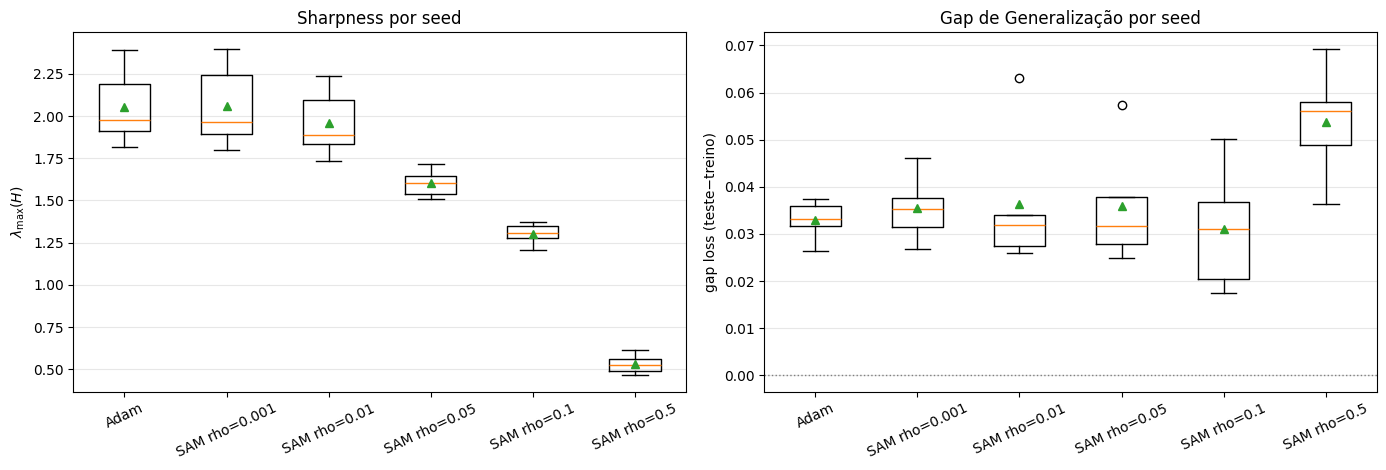

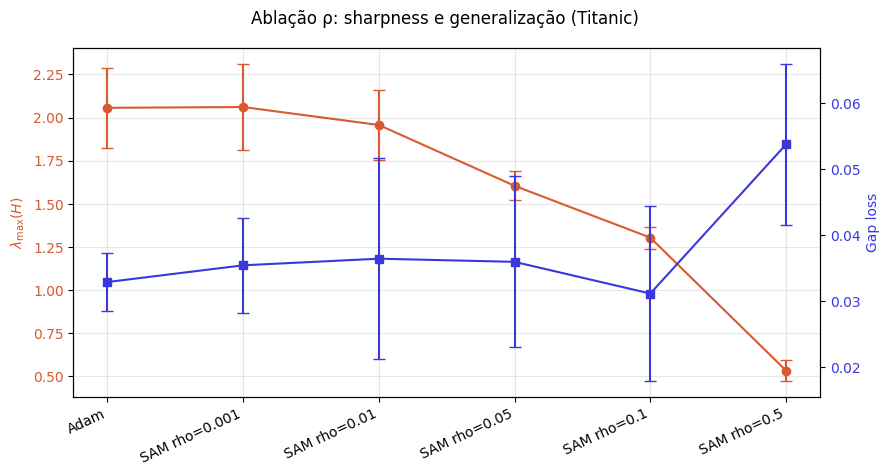

In [18]:
labels = list(summary_rho['nome'])
positions = np.arange(len(labels))
lambda_data = [df_rho.loc[df_rho['nome']==l, 'lambda_max'].values for l in labels]
gap_data    = [df_rho.loc[df_rho['nome']==l, 'gap_loss'].values   for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(lambda_data, labels=labels, showmeans=True)
axes[0].set_ylabel(r'$\lambda_{\max}(H)$'); axes[0].set_title('Sharpness por seed')
axes[0].grid(True, alpha=.3, axis='y'); axes[0].tick_params(axis='x', rotation=25)
axes[1].boxplot(gap_data, labels=labels, showmeans=True)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].set_ylabel('gap loss (teste−treino)'); axes[1].set_title('Gap de Generalização por seed')
axes[1].grid(True, alpha=.3, axis='y'); axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.errorbar(positions, summary_rho['lambda_mean'], yerr=summary_rho['lambda_std'],
             marker='o', capsize=4, color='#D85A30', label=r'$\lambda_{\max}$')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions); ax1.set_xticklabels(labels, rotation=25, ha='right')
ax1.grid(True, alpha=.3)
ax2 = ax1.twinx()
ax2.errorbar(positions, summary_rho['gap_loss_mean'], yerr=summary_rho['gap_loss_std'],
             marker='s', capsize=4, color='#3A37DD', label='gap loss')
ax2.set_ylabel('Gap loss', color='#3A37DD')
ax2.tick_params(axis='y', labelcolor='#3A37DD')
fig.suptitle('Ablação ρ: sharpness e generalização (Titanic)')
fig.tight_layout(); plt.show()

### Gráfico de Convergência do Método da Potência

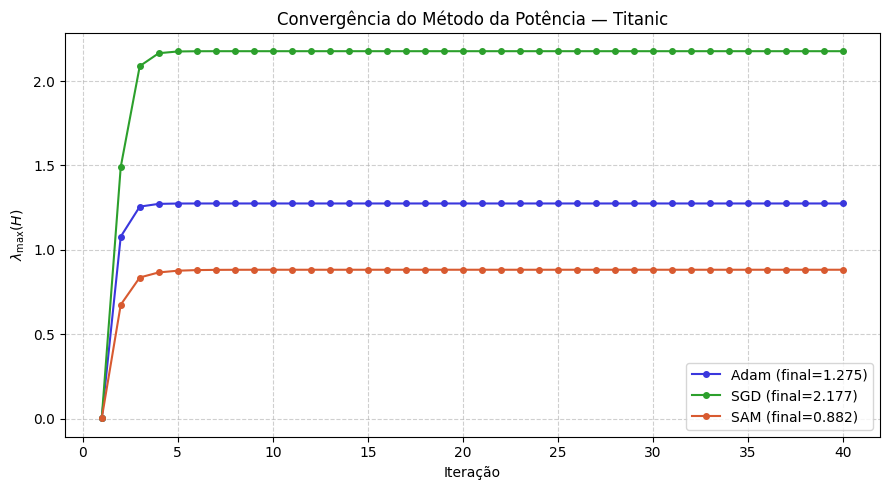

In [19]:
iterations = 40
hist_lam_adam, _ = calcular_autovalor_dominante_full(
    X_train_tensor, y_train_tensor, modelo_adam_tit, criterion_tit, iterations)
hist_lam_sam,  _ = calcular_autovalor_dominante_full(
    X_train_tensor, y_train_tensor, modelo_sam_tit,  criterion_tit, iterations)
hist_lam_sgd,  _ = calcular_autovalor_dominante_full(
    X_train_tensor, y_train_tensor, modelo_sgd_tit,  criterion_tit, iterations)

plt.figure(figsize=(9, 5))
for hist, label, cor in [
    (hist_lam_adam, 'Adam', '#3A37DD'),
    (hist_lam_sgd,  'SGD',  '#2ca02c'),
    (hist_lam_sam,  'SAM',  '#D85A30'),
]:
    plt.plot(range(1, len(hist)+1), hist, marker='o', markersize=4,
             label=f'{label} (final={hist[-1]:.3f})', color=cor)
plt.xlabel('Iteração'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('Convergência do Método da Potência — Titanic')
plt.legend(); plt.grid(True, ls='--', alpha=.6); plt.tight_layout(); plt.show()

### Geometria da Perda

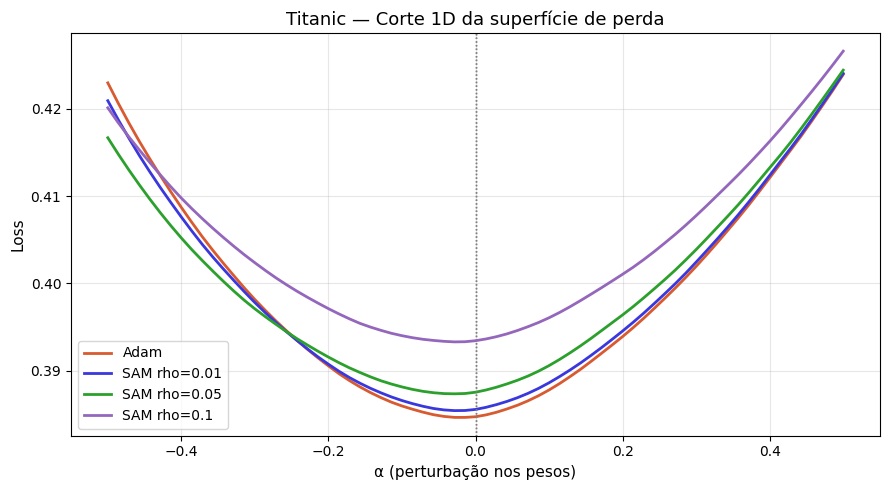

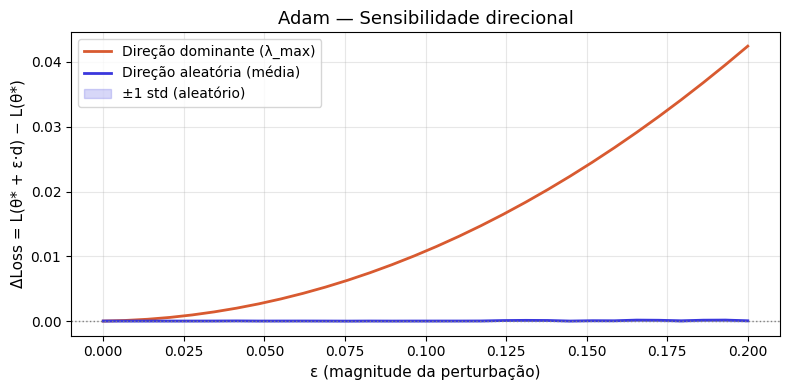

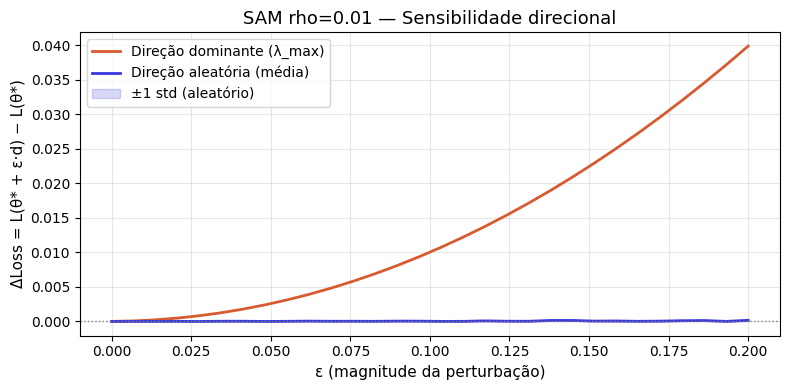

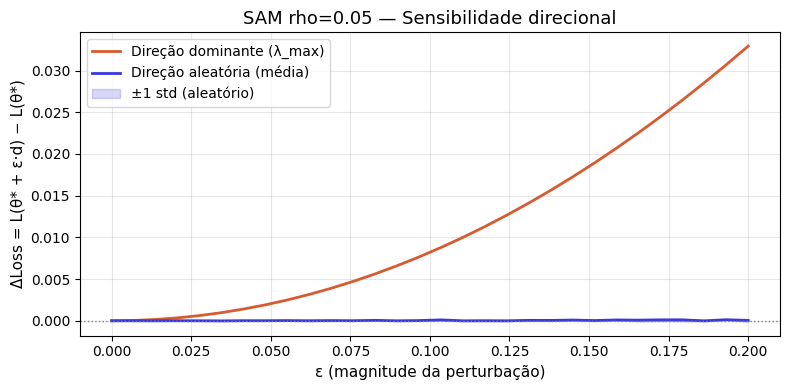

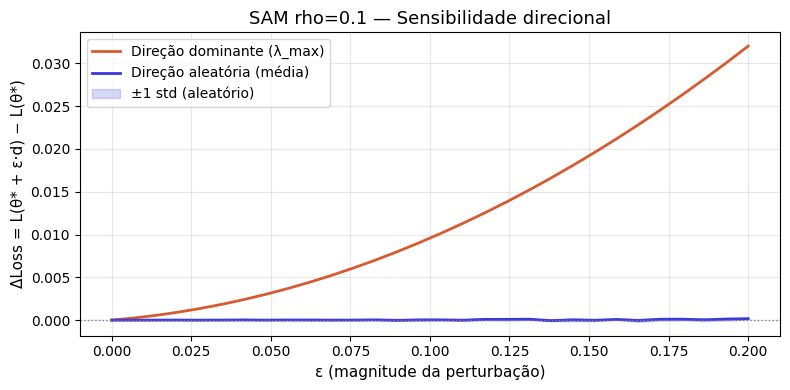

In [20]:
import sys; sys.path.append('.')
from loss_geometria import compare_models_1d, perturbation_experiment
from loss_geometria import compute_loss_landscape_2d

modelos_geometria = {
    'Adam': modelos_representativos['Adam'],
    'SAM rho=0.01': modelos_representativos.get('SAM rho=0.01', modelo_sam_tit),
    'SAM rho=0.05': modelos_representativos.get('SAM rho=0.05', modelo_sam_tit),
    'SAM rho=0.1':  modelos_representativos.get('SAM rho=0.1',  modelo_sam_tit),
}

compare_models_1d(
    models_dict=modelos_geometria,
    inputs=X_train_tensor, targets=y_train_tensor, criterion=criterion_tit,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='Titanic — Corte 1D da superfície de perda'
)
for nome, modelo in modelos_geometria.items():
    perturbation_experiment(modelo, X_train_tensor, y_train_tensor, criterion_tit,
                            epsilons=np.linspace(0, 0.2, 30), n_trials=5,
                            title=f'{nome} — Sensibilidade direcional')

Computing surface: Adam
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900
Computing surface: SAM rho=0.1
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900


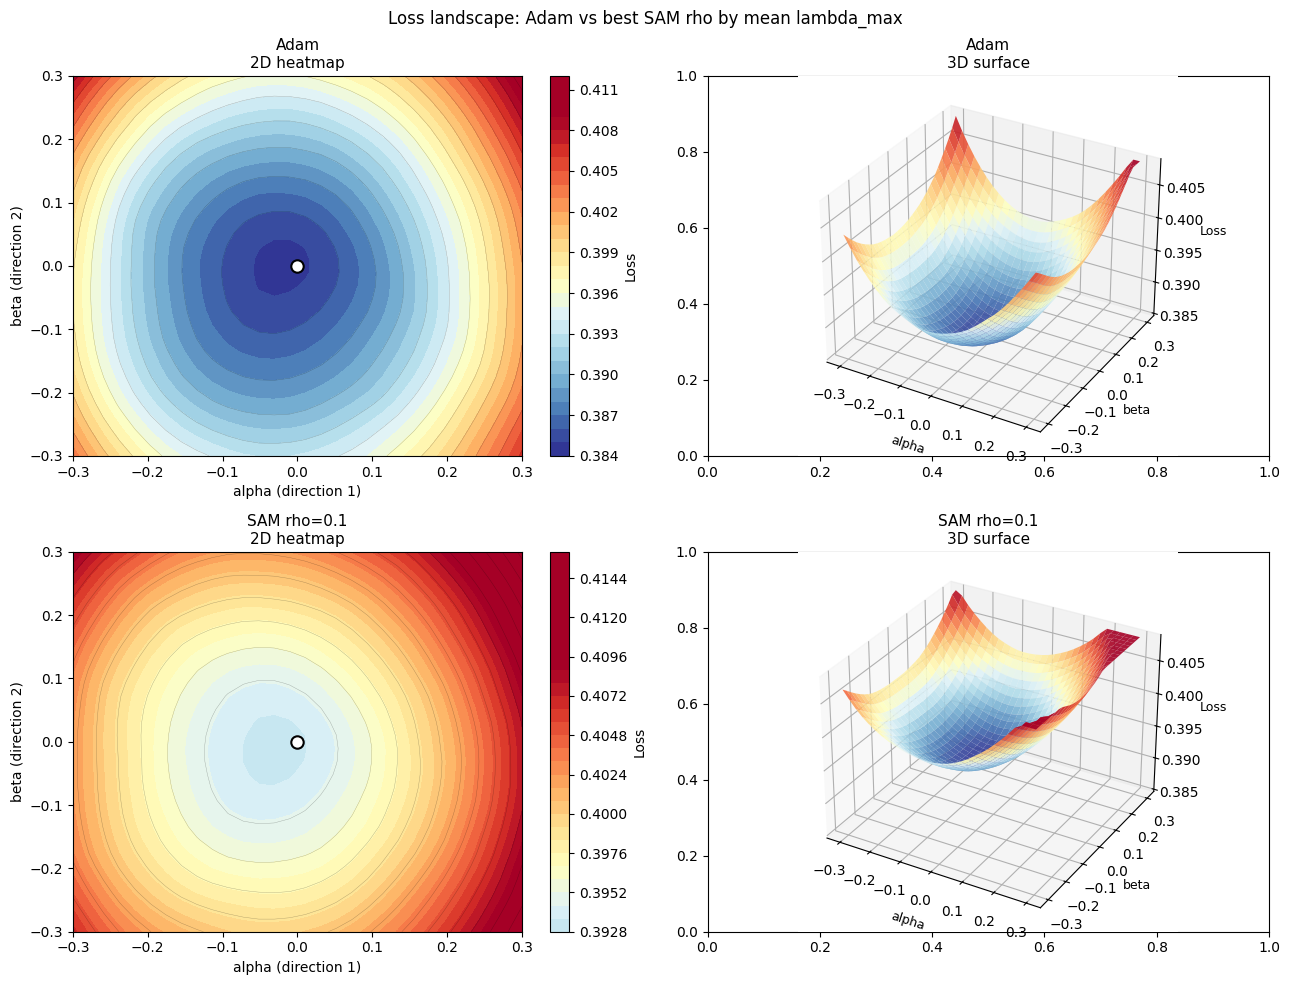

In [21]:
from loss_geometria import compute_loss_landscape_2d

# Adam vs melhor SAM rho (menor lambda_max médio na ablação)
sam_summary = summary_rho[summary_rho['nome'] != 'Adam'].copy()
best_sam_name = 'SAM rho=0.1'

modelo_adam_rep = modelos_representativos['Adam']
modelo_sam_rep  = modelos_representativos[best_sam_name]

alphas_zoom = np.linspace(-0.3, 0.3, 30)
betas_zoom  = np.linspace(-0.3, 0.3, 30)

print('Computing surface: Adam')
grid_adam = compute_loss_landscape_2d(
    modelo_adam_rep, X_train_tensor, y_train_tensor, criterion_tit,
    alphas=alphas_zoom, betas=betas_zoom)

print(f'Computing surface: {best_sam_name}')
grid_sam = compute_loss_landscape_2d(
    modelo_sam_rep, X_train_tensor, y_train_tensor, criterion_tit,
    alphas=alphas_zoom, betas=betas_zoom)

vmin_global = min(grid_adam.min(), grid_sam.min())
vmax_global = max(np.percentile(grid_adam, 95), np.percentile(grid_sam, 95))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (grid, nome) in enumerate([(grid_adam, 'Adam'), (grid_sam, best_sam_name)]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom, betas_zoom, grid,
                       levels=30, cmap='RdYlBu_r', vmin=vmin_global, vmax=vmax_global)
    ax_h.contour(alphas_zoom, betas_zoom, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5,
                 edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'{nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')

    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom, betas_zoom)
    Z = np.clip(grid, vmin_global, vmax_global)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_global, vmax_global)
    ax_3.set_xlabel('alpha', fontsize=9)
    ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'{nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)

fig.suptitle('Loss landscape: Adam vs best SAM rho by mean lambda_max')
fig.tight_layout()
plt.show()

### Evolução da Sharpness durante o Treino

  Época 10: λ_max = 1.2229
  Época 20: λ_max = 1.1189
  Época 30: λ_max = 1.0872
  Época 40: λ_max = 0.9341
  Early stopping na época 44.
  Época 10: λ_max = 0.6937
  Época 20: λ_max = 0.5534
  Época 30: λ_max = 0.5159
  Época 40: λ_max = 0.5032
  Early stopping na época 44.
  Época 10: λ_max = 1.9684
  Época 20: λ_max = 2.2760
  Época 30: λ_max = 2.6309
  Época 40: λ_max = 2.9497
  Época 50: λ_max = 3.3372
  Época 60: λ_max = 3.8752
  Early stopping na época 66.


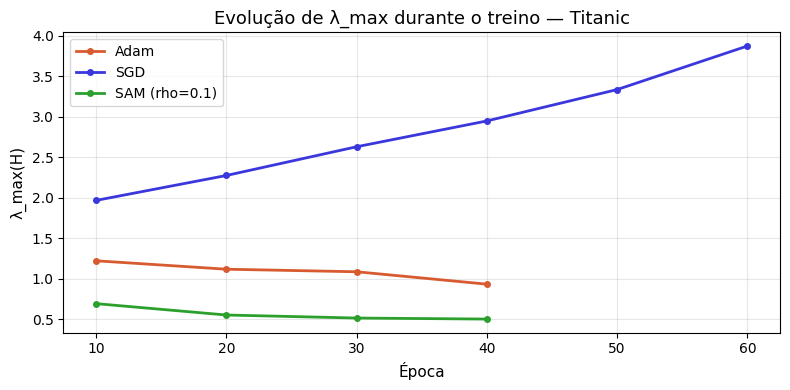

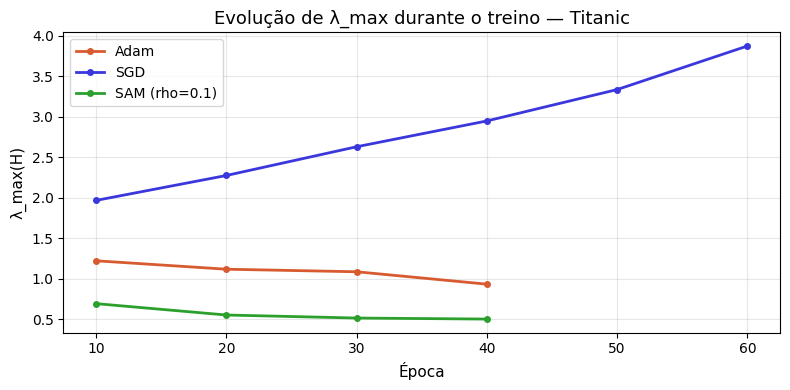

In [22]:
from loss_geometria import train_with_sharpness_tracking, plot_sharpness_over_time

set_seed(SEED)
_adam_track = MLP(input_dim_tit, [64, 32], 1)
hist_adam_track = train_with_sharpness_tracking(
    model=_adam_track, train_loader=train_loader_tit, val_loader=val_loader_tit,
    optimizer=optim.Adam(_adam_track.parameters(), lr=0.01, weight_decay=1e-4),
    criterion=criterion_tit, epochs=300, is_sam=False, patience=40,
    track_every=10, X_full=X_train_tensor, y_full=y_train_tensor)

set_seed(SEED)
_sam_track = MLP(input_dim_tit, [64, 32], 1)
hist_sam_track = train_with_sharpness_tracking(
    model=_sam_track, train_loader=train_loader_tit, val_loader=val_loader_tit,
    optimizer=SAM(_sam_track.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    criterion=criterion_tit, epochs=300, is_sam=True, patience=40,
    track_every=10, X_full=X_train_tensor, y_full=y_train_tensor)

set_seed(SEED)
_sgd_track = MLP(input_dim_tit, [64, 32], 1)
hist_sgd_track = train_with_sharpness_tracking(
    model=_sgd_track, train_loader=train_loader_tit, val_loader=val_loader_tit,
    optimizer=optim.SGD(_sgd_track.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    criterion=criterion_tit, epochs=300, is_sam=False, patience=40,
    track_every=10, X_full=X_train_tensor, y_full=y_train_tensor)

plot_sharpness_over_time(
    {'Adam': hist_adam_track, 'SGD': hist_sgd_track, 'SAM (rho=0.1)': hist_sam_track},
    title='Evolução de λ_max durante o treino — Titanic')

## Dataset 2: Iris (Classificação Multiclasse)

**Tarefa:** classificar 3 espécies de íris (multiclasse). **Critério:** CrossEntropyLoss.

### Pré-processamento

In [23]:
iris = load_iris()
X_iris_raw = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

X_tr_iris_raw, X_tmp_iris, y_tr_iris, y_tmp_iris = train_test_split(
    X_iris_raw, y_iris, test_size=0.4, stratify=y_iris, random_state=SEED)
X_val_iris_raw, X_te_iris_raw, y_val_iris, y_te_iris = train_test_split(
    X_tmp_iris, y_tmp_iris, test_size=0.5, stratify=y_tmp_iris, random_state=SEED)

scaler_iris = StandardScaler()
X_tr_iris  = scaler_iris.fit_transform(X_tr_iris_raw)
X_val_iris = scaler_iris.transform(X_val_iris_raw)
X_te_iris  = scaler_iris.transform(X_te_iris_raw)

X_tr_iris_t  = torch.tensor(X_tr_iris,  dtype=torch.float32)
X_val_iris_t = torch.tensor(X_val_iris, dtype=torch.float32)
X_te_iris_t  = torch.tensor(X_te_iris,  dtype=torch.float32)
y_tr_iris_t  = torch.tensor(y_tr_iris,  dtype=torch.long)
y_val_iris_t = torch.tensor(y_val_iris, dtype=torch.long)
y_te_iris_t  = torch.tensor(y_te_iris,  dtype=torch.long)

train_loader_iris = DataLoader(TensorDataset(X_tr_iris_t,  y_tr_iris_t),  batch_size=16, shuffle=True)
val_loader_iris   = DataLoader(TensorDataset(X_val_iris_t, y_val_iris_t), batch_size=16, shuffle=False)
test_loader_iris  = DataLoader(TensorDataset(X_te_iris_t,  y_te_iris_t),  batch_size=16, shuffle=False)

input_dim_iris = X_tr_iris_t.shape[1]
print(f'Iris: input_dim={input_dim_iris}  train={len(y_tr_iris)}  val={len(y_val_iris)}  test={len(y_te_iris)}')

Iris: input_dim=4  train=90  val=30  test=30


### Treinamento: Adam, SGD e SAM

In [24]:
EPOCAS_IRIS, PATIENCE_IRIS = 300, 30
criterion_iris = nn.CrossEntropyLoss()

# Adam
set_seed(SEED)
modelo_adam_iris = MLP(input_dim_iris, [16, 16], 3)
hist_adam_iris = train_model_multiclass(
    modelo_adam_iris, train_loader_iris, val_loader_iris,
    optim.Adam(modelo_adam_iris.parameters(), lr=0.01, weight_decay=1e-4),
    EPOCAS_IRIS, patience=PATIENCE_IRIS)
print(f'Adam  → {hist_adam_iris["epochs_trained"]} épocas')

# SGD
set_seed(SEED)
modelo_sgd_iris = MLP(input_dim_iris, [16, 16], 3)
hist_sgd_iris = train_model_multiclass(
    modelo_sgd_iris, train_loader_iris, val_loader_iris,
    optim.SGD(modelo_sgd_iris.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    EPOCAS_IRIS, patience=PATIENCE_IRIS)
print(f'SGD   → {hist_sgd_iris["epochs_trained"]} épocas')

# SAM + Adam
set_seed(SEED)
modelo_sam_iris = MLP(input_dim_iris, [16, 16], 3)
hist_sam_iris = train_model_multiclass(
    modelo_sam_iris, train_loader_iris, val_loader_iris,
    SAM(modelo_sam_iris.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    EPOCAS_IRIS, is_sam=True, patience=PATIENCE_IRIS)
print(f'SAM   → {hist_sam_iris["epochs_trained"]} épocas')

historicos_iris = {'Adam': hist_adam_iris, 'SGD': hist_sgd_iris, 'SAM': hist_sam_iris}

Adam  → 101 épocas
SGD   → 300 épocas
SAM   → 105 épocas


### Curvas de Aprendizado

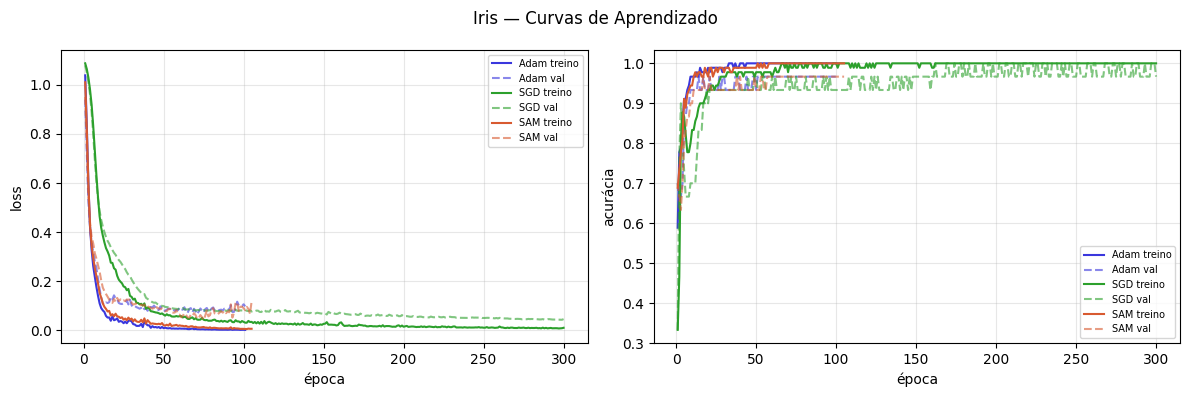

In [25]:
plot_comparacao(historicos_iris, title='Iris — Curvas de Aprendizado')

### Métricas Finais e Gap de Generalização

Adam
  treino: loss=0.0042  acc=1.000
  val:    loss=0.0655  acc=0.967
  teste:  loss=0.3120  acc=0.933
  gap (treino-teste acc): 0.067
SGD
  treino: loss=0.0075  acc=1.000
  val:    loss=0.0431  acc=1.000
  teste:  loss=0.3015  acc=0.900
  gap (treino-teste acc): 0.100
SAM
  treino: loss=0.0129  acc=1.000
  val:    loss=0.0422  acc=0.967
  teste:  loss=0.2080  acc=0.933
  gap (treino-teste acc): 0.067


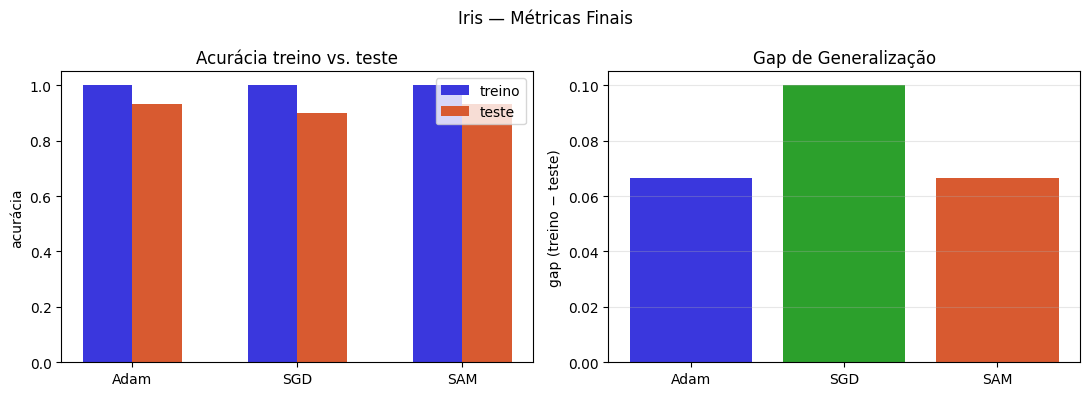

In [26]:
resultados_iris = {}
for nome, modelo in [('Adam', modelo_adam_iris), ('SGD', modelo_sgd_iris), ('SAM', modelo_sam_iris)]:
    resultados_iris[nome] = resumir_resultados(
        nome, modelo, train_loader_iris, val_loader_iris, test_loader_iris, is_binary=False)

plot_metricas_barras(resultados_iris, title='Iris — Métricas Finais')

### Sharpness (λ_max da Hessiana)

Adam: λ_max = 3.0160
SGD: λ_max = 4.7874
SAM: λ_max = 1.6451


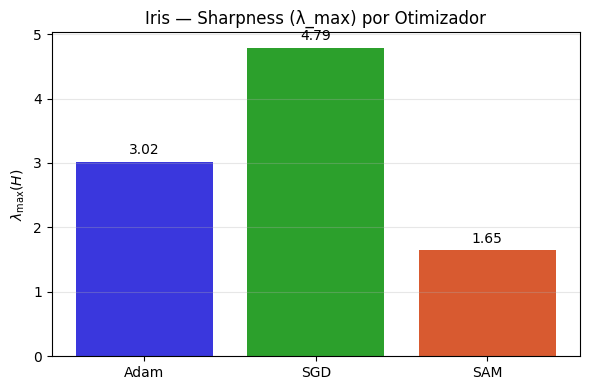

In [27]:
lambdas_iris = {}
for nome, modelo in [('Adam', modelo_adam_iris), ('SGD', modelo_sgd_iris), ('SAM', modelo_sam_iris)]:
    lam = get_lambda_max(modelo, X_tr_iris_t, y_tr_iris_t, criterion_iris,
                         num_iterations=30, seed=SEED)
    lambdas_iris[nome] = lam
    print(f'{nome}: λ_max = {lam:.4f}')

plot_lambda_bar(lambdas_iris, title='Iris — Sharpness (λ_max) por Otimizador')

## Análise Adicional SAM — Ablação de ρ (Iris)

Mesma estrutura do Titanic: 5 seeds × 6 valores de ρ, base Adam.

In [28]:
resultados_rho_iris = []
modelos_representativos_iris = {}

for seed in SEEDS_EXPERIMENTO:
    print(f"\n{'#'*60}\nSEED {seed}\n{'#'*60}")
    for cfg in configuracoes_rho:
        nome, rho, is_sam = cfg['nome'], cfg['rho'], cfg['is_sam']
        print(f'\n--- {nome} ---')
        set_seed(seed)
        model = MLP(input_dim_iris, [16, 16], 3)
        gen = torch.Generator().manual_seed(seed)
        loader_seed = DataLoader(TensorDataset(X_tr_iris_t, y_tr_iris_t),
                                  batch_size=16, shuffle=True, generator=gen)
        if is_sam:
            optimizer = SAM(model.parameters(), optim.Adam,
                            lr=0.01, weight_decay=BASE_WEIGHT_DECAY, rho=rho)
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=BASE_WEIGHT_DECAY)
        history = train_model_multiclass(model, loader_seed, val_loader_iris,
                                          optimizer, BASE_EPOCHS,
                                          is_sam=is_sam, patience=PATIENCE_IRIS)
        tm = evaluate_multiclass(model, train_loader_iris)
        vm = evaluate_multiclass(model, val_loader_iris)
        sm = evaluate_multiclass(model, test_loader_iris)
        gap_loss = sm['loss'] - tm['loss']
        gap_acc  = tm['accuracy'] - sm['accuracy']
        lam = get_lambda_max(model, X_tr_iris_t, y_tr_iris_t, criterion_iris,
                              num_iterations=30, seed=seed)
        print(f"ep={history['epochs_trained']:>3} train={tm['loss']:.4f} "
              f"test={sm['loss']:.4f} gap={gap_loss:+.4f} λ_max={lam:.4f}")
        resultados_rho_iris.append({
            'seed': seed, 'nome': nome, 'rho': 'Adam' if rho is None else rho,
            'is_sam': is_sam, 'epochs': history['epochs_trained'],
            'train_loss': tm['loss'], 'val_loss': vm['loss'], 'test_loss': sm['loss'],
            'train_acc': tm['accuracy'], 'val_acc': vm['accuracy'], 'test_acc': sm['accuracy'],
            'gap_loss': gap_loss, 'gap_acc': gap_acc, 'lambda_max': lam,
        })
        if seed == SEEDS_EXPERIMENTO[0]:
            modelos_representativos_iris[nome] = copy.deepcopy(model)


############################################################
SEED 0
############################################################

--- Adam ---
ep= 87 train=0.0145 test=0.3346 gap=+0.3201 λ_max=4.3046

--- SAM rho=0.001 ---
ep= 87 train=0.0138 test=0.3211 gap=+0.3073 λ_max=4.2446

--- SAM rho=0.01 ---
ep= 87 train=0.0134 test=0.3121 gap=+0.2987 λ_max=4.0691

--- SAM rho=0.05 ---
ep= 82 train=0.0157 test=0.2399 gap=+0.2242 λ_max=2.7393

--- SAM rho=0.1 ---
ep=114 train=0.0121 test=0.2130 gap=+0.2009 λ_max=1.6013

--- SAM rho=0.5 ---
ep=113 train=0.0423 test=0.1414 gap=+0.0992 λ_max=0.6445

############################################################
SEED 1
############################################################

--- Adam ---
ep=102 train=0.0149 test=0.3039 gap=+0.2890 λ_max=4.8588

--- SAM rho=0.001 ---
ep=102 train=0.0111 test=0.2726 gap=+0.2614 λ_max=4.5123

--- SAM rho=0.01 ---
ep=102 train=0.0101 test=0.2729 gap=+0.2628 λ_max=4.0895

--- SAM rho=0.05 ---
ep= 91 train=0.0173 tes

In [29]:
df_rho_iris = pd.DataFrame(resultados_rho_iris)

summary_rho_iris = (
    df_rho_iris.groupby('nome', sort=False)
    .agg(lambda_mean=('lambda_max','mean'), lambda_std=('lambda_max','std'),
         gap_loss_mean=('gap_loss','mean'), gap_loss_std=('gap_loss','std'),
         test_acc_mean=('test_acc','mean'), test_acc_std=('test_acc','std'),
         epochs_mean=('epochs','mean'))
    .reset_index()
)

print('Iris — Mean +/- std por configuração:')
for _, row in summary_rho_iris.iterrows():
    print(f"{row['nome']:<14} "
          f"λ={row['lambda_mean']:.4f}±{row['lambda_std']:.4f} "
          f"gap={row['gap_loss_mean']:+.4f}±{row['gap_loss_std']:.4f} "
          f"test_acc={row['test_acc_mean']:.3f}±{row['test_acc_std']:.3f}")

Iris — Mean +/- std por configuração:
Adam           λ=4.0581±0.6676 gap=+0.3320±0.1821 test_acc=0.927±0.028
SAM rho=0.001  λ=3.9421±0.6109 gap=+0.3229±0.1844 test_acc=0.927±0.028
SAM rho=0.01   λ=3.7630±0.5374 gap=+0.2760±0.1337 test_acc=0.927±0.028
SAM rho=0.05   λ=2.9511±0.1441 gap=+0.2225±0.1274 test_acc=0.927±0.028
SAM rho=0.1    λ=1.7986±0.3628 gap=+0.2649±0.2108 test_acc=0.933±0.024
SAM rho=0.5    λ=0.5971±0.0465 gap=+0.0825±0.0217 test_acc=0.940±0.015


/tmp/ipykernel_217943/9674593.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(lambda_data_iris, labels=labels_iris, showmeans=True)
/tmp/ipykernel_217943/9674593.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(gap_data_iris, labels=labels_iris, showmeans=True)


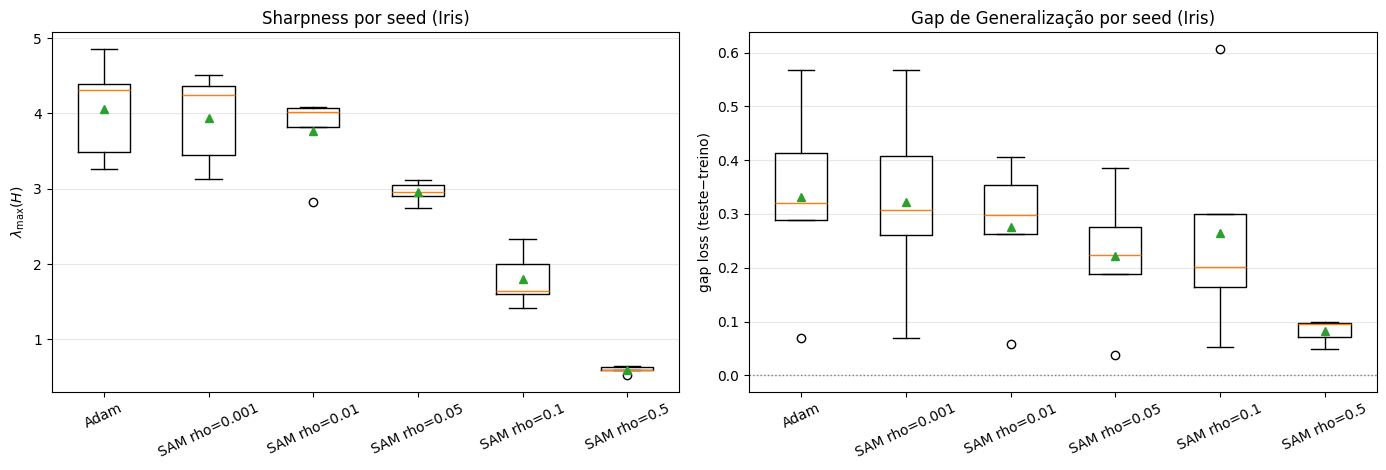

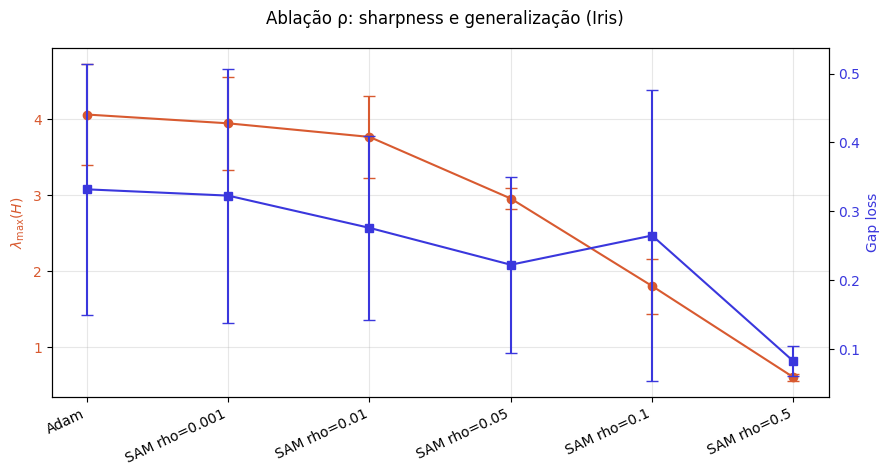

In [30]:
labels_iris = list(summary_rho_iris['nome'])
positions_iris = np.arange(len(labels_iris))
lambda_data_iris = [df_rho_iris.loc[df_rho_iris['nome']==l, 'lambda_max'].values for l in labels_iris]
gap_data_iris    = [df_rho_iris.loc[df_rho_iris['nome']==l, 'gap_loss'].values   for l in labels_iris]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(lambda_data_iris, labels=labels_iris, showmeans=True)
axes[0].set_ylabel(r'$\lambda_{\max}(H)$'); axes[0].set_title('Sharpness por seed (Iris)')
axes[0].grid(True, alpha=.3, axis='y'); axes[0].tick_params(axis='x', rotation=25)
axes[1].boxplot(gap_data_iris, labels=labels_iris, showmeans=True)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].set_ylabel('gap loss (teste−treino)'); axes[1].set_title('Gap de Generalização por seed (Iris)')
axes[1].grid(True, alpha=.3, axis='y'); axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.errorbar(positions_iris, summary_rho_iris['lambda_mean'], yerr=summary_rho_iris['lambda_std'],
             marker='o', capsize=4, color='#D85A30', label=r'$\lambda_{\max}$')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions_iris); ax1.set_xticklabels(labels_iris, rotation=25, ha='right')
ax1.grid(True, alpha=.3)
ax2 = ax1.twinx()
ax2.errorbar(positions_iris, summary_rho_iris['gap_loss_mean'], yerr=summary_rho_iris['gap_loss_std'],
             marker='s', capsize=4, color='#3A37DD', label='gap loss')
ax2.set_ylabel('Gap loss', color='#3A37DD')
ax2.tick_params(axis='y', labelcolor='#3A37DD')
fig.suptitle('Ablação ρ: sharpness e generalização (Iris)')
fig.tight_layout(); plt.show()

### Gráfico de Convergência do Método da Potência — Iris

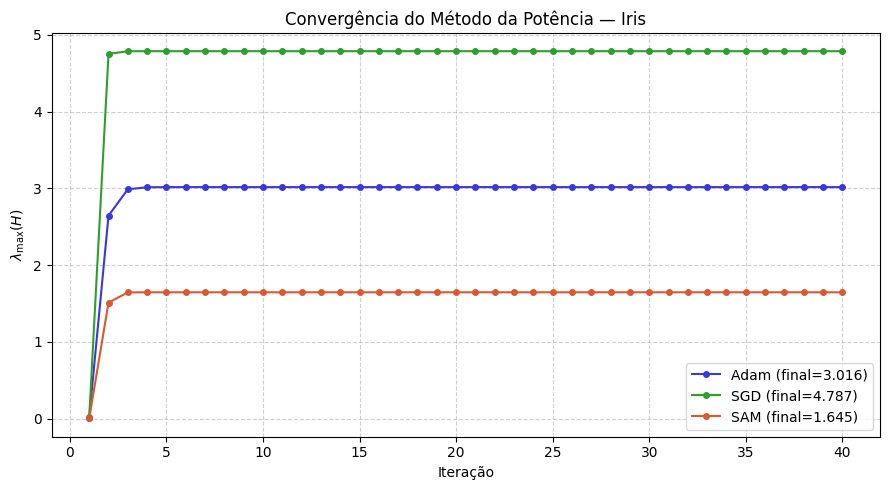

In [31]:
iterations_iris = 40
hist_lam_adam_iris, _ = calcular_autovalor_dominante_full(
    X_tr_iris_t, y_tr_iris_t, modelo_adam_iris, criterion_iris, iterations_iris)
hist_lam_sgd_iris,  _ = calcular_autovalor_dominante_full(
    X_tr_iris_t, y_tr_iris_t, modelo_sgd_iris,  criterion_iris, iterations_iris)
hist_lam_sam_iris,  _ = calcular_autovalor_dominante_full(
    X_tr_iris_t, y_tr_iris_t, modelo_sam_iris,  criterion_iris, iterations_iris)

plt.figure(figsize=(9, 5))
for hist, label, cor in [
    (hist_lam_adam_iris, 'Adam', '#3A37DD'),
    (hist_lam_sgd_iris,  'SGD',  '#2ca02c'),
    (hist_lam_sam_iris,  'SAM',  '#D85A30'),
]:
    plt.plot(range(1, len(hist)+1), hist, marker='o', markersize=4,
             label=f'{label} (final={hist[-1]:.3f})', color=cor)
plt.xlabel('Iteração'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('Convergência do Método da Potência — Iris')
plt.legend(); plt.grid(True, ls='--', alpha=.6); plt.tight_layout(); plt.show()

### Geometria da Perda — Iris

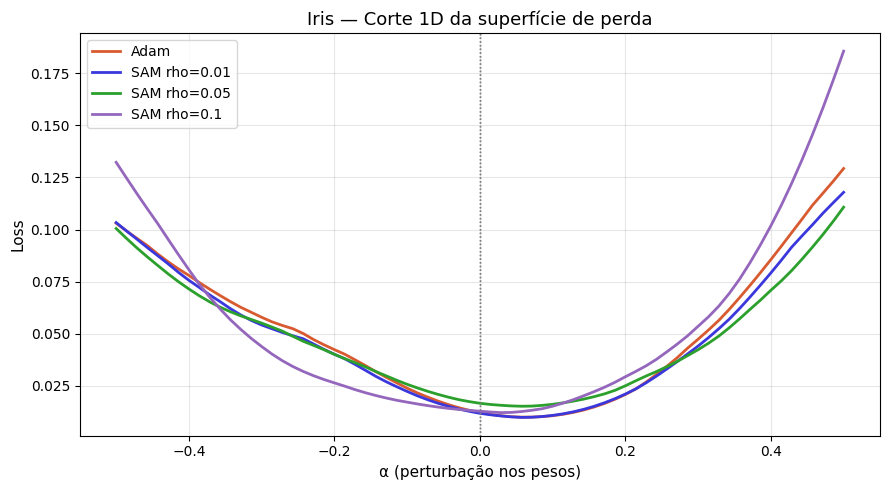

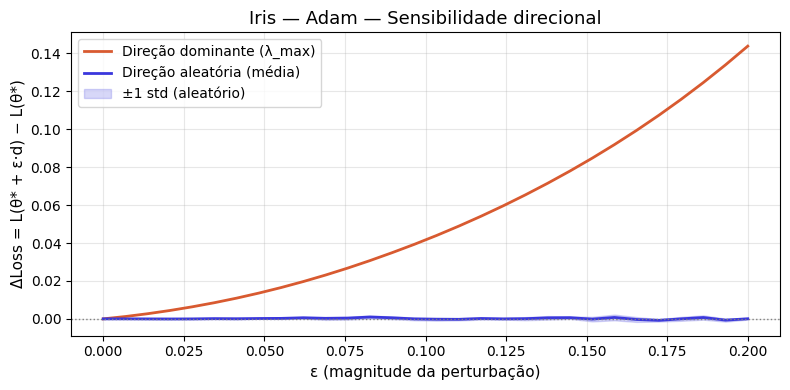

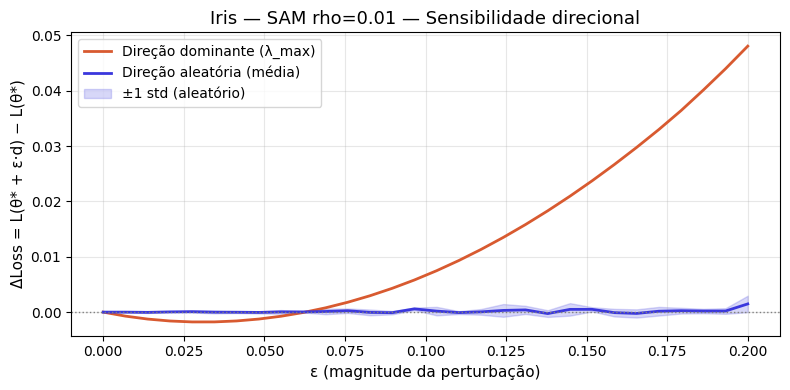

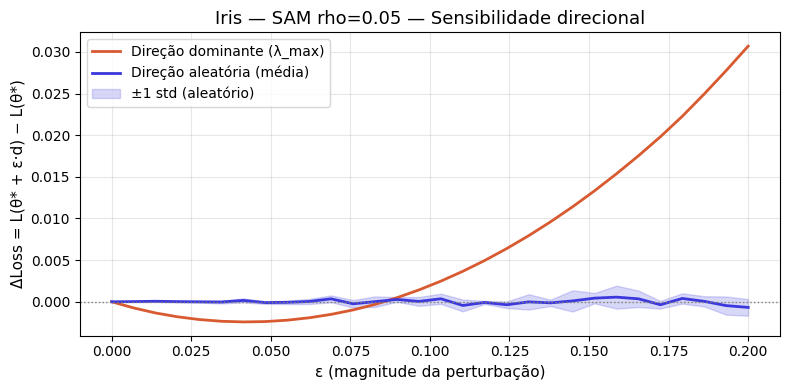

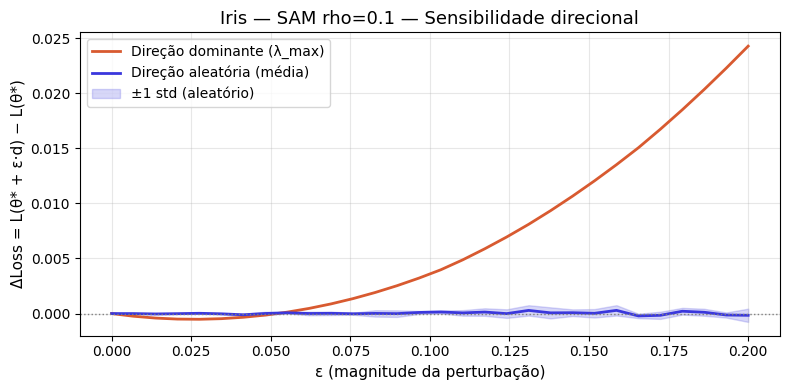

In [32]:
modelos_geo_iris = {
    'Adam': modelos_representativos_iris['Adam'],
    'SAM rho=0.01': modelos_representativos_iris.get('SAM rho=0.01', modelo_sam_iris),
    'SAM rho=0.05': modelos_representativos_iris.get('SAM rho=0.05', modelo_sam_iris),
    'SAM rho=0.1':  modelos_representativos_iris.get('SAM rho=0.1',  modelo_sam_iris),
}

compare_models_1d(
    models_dict=modelos_geo_iris,
    inputs=X_tr_iris_t, targets=y_tr_iris_t, criterion=criterion_iris,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='Iris — Corte 1D da superfície de perda'
)
for nome, modelo in modelos_geo_iris.items():
    perturbation_experiment(modelo, X_tr_iris_t, y_tr_iris_t, criterion_iris,
                            epsilons=np.linspace(0, 0.2, 30), n_trials=5,
                            title=f'Iris — {nome} — Sensibilidade direcional')

Computing surface: Adam
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900
Computing surface: SAM rho=0.1
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900


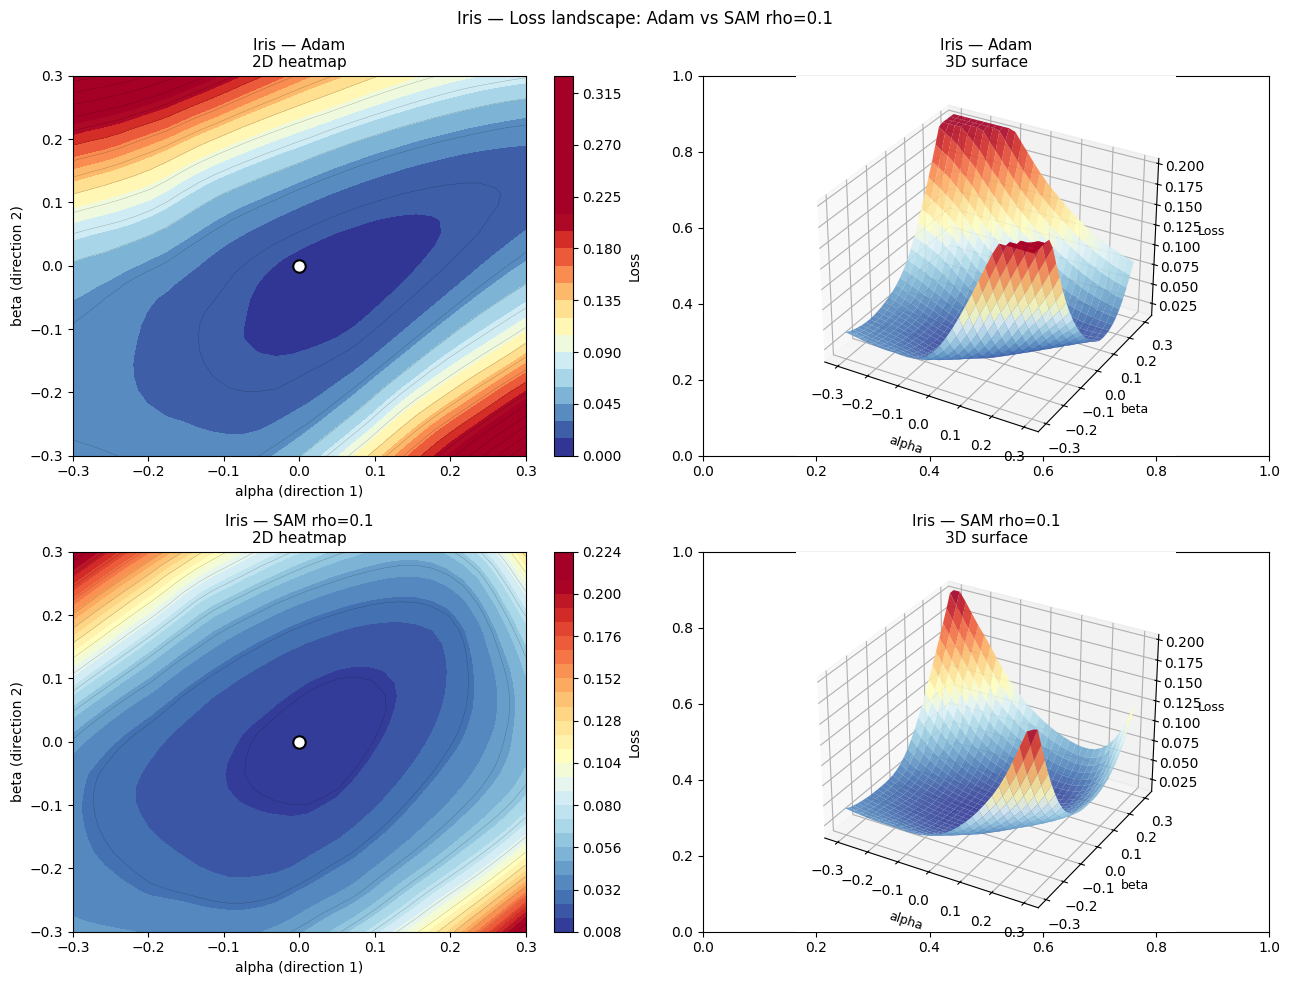

In [33]:
sam_summary_iris = summary_rho_iris[summary_rho_iris['nome'] != 'Adam'].copy()
best_sam_name_iris = 'SAM rho=0.1'

modelo_adam_rep_iris = modelos_representativos_iris['Adam']
modelo_sam_rep_iris  = modelos_representativos_iris[best_sam_name_iris]

alphas_zoom_iris = np.linspace(-0.3, 0.3, 30)
betas_zoom_iris  = np.linspace(-0.3, 0.3, 30)

print('Computing surface: Adam')
grid_adam_iris = compute_loss_landscape_2d(
    modelo_adam_rep_iris, X_tr_iris_t, y_tr_iris_t, criterion_iris,
    alphas=alphas_zoom_iris, betas=betas_zoom_iris)
print(f'Computing surface: {best_sam_name_iris}')
grid_sam_iris = compute_loss_landscape_2d(
    modelo_sam_rep_iris, X_tr_iris_t, y_tr_iris_t, criterion_iris,
    alphas=alphas_zoom_iris, betas=betas_zoom_iris)

vmin_iris = min(grid_adam_iris.min(), grid_sam_iris.min())
vmax_iris = max(np.percentile(grid_adam_iris, 95), np.percentile(grid_sam_iris, 95))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (grid, nome) in enumerate([(grid_adam_iris, 'Adam'), (grid_sam_iris, best_sam_name_iris)]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom_iris, betas_zoom_iris, grid,
                       levels=30, cmap='RdYlBu_r', vmin=vmin_iris, vmax=vmax_iris)
    ax_h.contour(alphas_zoom_iris, betas_zoom_iris, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5, edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'Iris — {nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')
    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom_iris, betas_zoom_iris)
    Z = np.clip(grid, vmin_iris, vmax_iris)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_iris, vmax_iris)
    ax_3.set_xlabel('alpha', fontsize=9); ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'Iris — {nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)
fig.suptitle(f'Iris — Loss landscape: Adam vs {best_sam_name_iris}')
fig.tight_layout(); plt.show()

### Evolução da Sharpness durante o Treino — Iris

In [ ]:
set_seed(SEED)
_adam_iris_track = MLP(input_dim_iris, [16, 16], 3)
hist_adam_iris_track = train_with_sharpness_tracking(
    model=_adam_iris_track, train_loader=train_loader_iris, val_loader=val_loader_iris,
    optimizer=optim.Adam(_adam_iris_track.parameters(), lr=0.01, weight_decay=1e-4),
    criterion=criterion_iris, epochs=EPOCAS_IRIS, is_sam=False, patience=PATIENCE_IRIS,
    track_every=10, X_full=X_tr_iris_t, y_full=y_tr_iris_t)

set_seed(SEED)
_sgd_iris_track = MLP(input_dim_iris, [16, 16], 3)
hist_sgd_iris_track = train_with_sharpness_tracking(
    model=_sgd_iris_track, train_loader=train_loader_iris, val_loader=val_loader_iris,
    optimizer=optim.SGD(_sgd_iris_track.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    criterion=criterion_iris, epochs=EPOCAS_IRIS, is_sam=False, patience=PATIENCE_IRIS,
    track_every=10, X_full=X_tr_iris_t, y_full=y_tr_iris_t)

set_seed(SEED)
_sam_iris_track = MLP(input_dim_iris, [16, 16], 3)
hist_sam_iris_track = train_with_sharpness_tracking(
    model=_sam_iris_track, train_loader=train_loader_iris, val_loader=val_loader_iris,
    optimizer=SAM(_sam_iris_track.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    criterion=criterion_iris, epochs=EPOCAS_IRIS, is_sam=True, patience=PATIENCE_IRIS,
    track_every=10, X_full=X_tr_iris_t, y_full=y_tr_iris_t)

plot_sharpness_over_time(
    {'Adam': hist_adam_iris_track, 'SGD': hist_sgd_iris_track, 'SAM (rho=0.1)': hist_sam_iris_track},
    title='Evolução de λ_max durante o treino — Iris')

  Época 10: λ_max = 5.9251
  Época 20: λ_max = 5.7652
  Época 30: λ_max = 6.0740
  Época 40: λ_max = 6.7266
  Early stopping na época 44.
  Época 10: λ_max = 1.8924
  Época 20: λ_max = 4.1703
  Época 30: λ_max = 5.0565
  Época 40: λ_max = 5.2167
  Época 50: λ_max = 5.3072
  Época 60: λ_max = 5.4155
  Época 70: λ_max = 5.4948
  Época 80: λ_max = 5.5523
  Época 90: λ_max = 5.5756
  Época 100: λ_max = 5.5979
  Época 110: λ_max = 5.6097
  Época 120: λ_max = 5.6250
  Época 130: λ_max = 5.6553
  Época 140: λ_max = 5.6615
  Época 150: λ_max = 5.6837
  Época 160: λ_max = 5.7111
  Época 170: λ_max = 5.7198
  Época 180: λ_max = 5.7359
  Época 190: λ_max = 5.7118
  Época 200: λ_max = 5.7028
  Época 210: λ_max = 5.6998
  Época 220: λ_max = 5.6729
  Época 230: λ_max = 5.6546
  Época 240: λ_max = 5.5807
  Época 250: λ_max = 5.5032
  Época 260: λ_max = 5.4475
  Época 270: λ_max = 5.3901
  Época 280: λ_max = 5.3056
  Época 290: λ_max = 5.2372
  Época 300: λ_max = 5.1586
  Época 10: λ_max = 3.7696


## Dataset 3: FashionMNIST (Classificação Multiclasse)

**Tarefa:** classificar 10 categorias de roupa. **Critério:** CrossEntropyLoss.
CNN com 2 blocos Conv(32/64)+ReLU+MaxPool2d, FC 256 (~220k parâmetros). Imagens 1×28×28.

### Pré-processamento

In [ ]:
tf_fm = T.Compose([T.ToTensor(), T.Normalize((0.286,), (0.353,))])
train_full_fm = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=tf_fm)
test_full_fm  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=tf_fm)

N_TRAIN_FM, N_TEST_FM = 6000, 1500
train_ds_fm = Subset(train_full_fm, range(N_TRAIN_FM))
test_ds_fm  = Subset(test_full_fm,  range(N_TEST_FM))

def extract_tensors(dataset, n):
    X = torch.stack([dataset[i][0] for i in range(n)])
    y = torch.tensor([dataset[i][1] for i in range(n)], dtype=torch.long)
    return X, y

X_all_fm, y_all_fm = extract_tensors(train_ds_fm, N_TRAIN_FM)
X_te_fm,  y_te_fm  = extract_tensors(test_ds_fm,  N_TEST_FM)

X_tr_fm, X_val_fm, y_tr_fm, y_val_fm = train_test_split(
    X_all_fm, y_all_fm, test_size=0.15, random_state=SEED)

input_dim_fm = X_tr_fm.shape[1] * X_tr_fm.shape[2] * X_tr_fm.shape[3]  # 1*28*28 = 784 (achatado p/ MLP)

train_loader_fm = DataLoader(TensorDataset(X_tr_fm,  y_tr_fm),  batch_size=128, shuffle=True)
val_loader_fm   = DataLoader(TensorDataset(X_val_fm, y_val_fm), batch_size=256, shuffle=False)
test_loader_fm  = DataLoader(TensorDataset(X_te_fm,  y_te_fm),  batch_size=256, shuffle=False)

hx_fm = X_tr_fm[:1000]
hy_fm = y_tr_fm[:1000]

print(f'FashionMNIST: shape={tuple(X_tr_fm.shape[1:])}  train={len(y_tr_fm)}  val={len(y_val_fm)}  test={len(y_te_fm)}')


### Treinamento: Adam, SGD e SAM

In [ ]:
EPOCAS_FM, PATIENCE_FM = 20, 5
criterion_fm = nn.CrossEntropyLoss()

# Adam
set_seed(SEED)
modelo_adam_fm = MLP(input_dim_fm, [128, 64], 10)
hist_adam_fm = train_model_multiclass(
    modelo_adam_fm, train_loader_fm, val_loader_fm,
    optim.Adam(modelo_adam_fm.parameters(), lr=0.01, weight_decay=1e-4),
    EPOCAS_FM, patience=PATIENCE_FM)
print(f'Adam  → {hist_adam_fm["epochs_trained"]} épocas')

# SGD
set_seed(SEED)
modelo_sgd_fm = MLP(input_dim_fm, [128, 64], 10)
hist_sgd_fm = train_model_multiclass(
    modelo_sgd_fm, train_loader_fm, val_loader_fm,
    optim.SGD(modelo_sgd_fm.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    EPOCAS_FM, patience=PATIENCE_FM)
print(f'SGD   → {hist_sgd_fm["epochs_trained"]} épocas')

# SAM + Adam
set_seed(SEED)
modelo_sam_fm = MLP(input_dim_fm, [128, 64], 10)
hist_sam_fm = train_model_multiclass(
    modelo_sam_fm, train_loader_fm, val_loader_fm,
    SAM(modelo_sam_fm.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    EPOCAS_FM, is_sam=True, patience=PATIENCE_FM)
print(f'SAM   → {hist_sam_fm["epochs_trained"]} épocas')

historicos_fm = {'Adam': hist_adam_fm, 'SGD': hist_sgd_fm, 'SAM': hist_sam_fm}

### Curvas de Aprendizado

In [ ]:
plot_comparacao(historicos_fm, title='FashionMNIST — Curvas de Aprendizado')

### Métricas Finais e Gap de Generalização

In [ ]:
resultados_fm = {}
for nome, modelo in [('Adam', modelo_adam_fm), ('SGD', modelo_sgd_fm), ('SAM', modelo_sam_fm)]:
    resultados_fm[nome] = resumir_resultados(
        nome, modelo, train_loader_fm, val_loader_fm, test_loader_fm, is_binary=False)

plot_metricas_barras(resultados_fm, title='FashionMNIST — Métricas Finais')

### Sharpness (λ_max da Hessiana)

In [ ]:
lambdas_fm = {}
for nome, modelo in [('Adam', modelo_adam_fm), ('SGD', modelo_sgd_fm), ('SAM', modelo_sam_fm)]:
    lam = get_lambda_max(modelo, hx_fm, hy_fm, criterion_fm,
                         num_iterations=20, seed=SEED)
    lambdas_fm[nome] = lam
    print(f'{nome}: λ_max = {lam:.4f}')

plot_lambda_bar(lambdas_fm, title='FashionMNIST — Sharpness (λ_max) por Otimizador')

## Análise Adicional SAM — Ablação de ρ (FashionMNIST, base Adam)

Mesma estrutura do Titanic: 3 seeds × 6 valores de ρ, base Adam.
Usa subconjunto de treino para velocidade.

In [ ]:
SEEDS_FM_ADAM = [0, 1, 2]
resultados_rho_fm = []
modelos_representativos_fm = {}

for seed in SEEDS_FM_ADAM:
    print(f"\n{'#'*60}\nSEED {seed}\n{'#'*60}")
    for cfg in configuracoes_rho:
        nome, rho, is_sam = cfg['nome'], cfg['rho'], cfg['is_sam']
        print(f'\n--- {nome} ---')
        set_seed(seed)
        model = MLP(input_dim_fm, [128, 64], 10)
        gen = torch.Generator().manual_seed(seed)
        loader_seed = DataLoader(TensorDataset(X_tr_fm, y_tr_fm),
                                  batch_size=128, shuffle=True, generator=gen)
        if is_sam:
            optimizer = SAM(model.parameters(), optim.Adam,
                            lr=0.01, weight_decay=BASE_WEIGHT_DECAY, rho=rho)
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=BASE_WEIGHT_DECAY)
        history = train_model_multiclass(model, loader_seed, val_loader_fm,
                                          optimizer, EPOCAS_FM,
                                          is_sam=is_sam, patience=PATIENCE_FM)
        tm = evaluate_multiclass(model, train_loader_fm)
        vm = evaluate_multiclass(model, val_loader_fm)
        sm = evaluate_multiclass(model, test_loader_fm)
        gap_loss = sm['loss'] - tm['loss']
        gap_acc  = tm['accuracy'] - sm['accuracy']
        lam = get_lambda_max(model, hx_fm, hy_fm, criterion_fm,
                              num_iterations=20, seed=seed)
        print(f"ep={history['epochs_trained']:>3} train={tm['loss']:.4f} "
              f"test={sm['loss']:.4f} gap={gap_loss:+.4f} λ_max={lam:.4f}")
        resultados_rho_fm.append({
            'seed': seed, 'nome': nome, 'rho': 'Adam' if rho is None else rho,
            'is_sam': is_sam, 'epochs': history['epochs_trained'],
            'train_loss': tm['loss'], 'val_loss': vm['loss'], 'test_loss': sm['loss'],
            'train_acc': tm['accuracy'], 'val_acc': vm['accuracy'], 'test_acc': sm['accuracy'],
            'gap_loss': gap_loss, 'gap_acc': gap_acc, 'lambda_max': lam,
        })
        if seed == SEEDS_FM_ADAM[0]:
            modelos_representativos_fm[nome] = copy.deepcopy(model)

In [ ]:
df_rho_fm = pd.DataFrame(resultados_rho_fm)

summary_rho_fm = (
    df_rho_fm.groupby('nome', sort=False)
    .agg(lambda_mean=('lambda_max','mean'), lambda_std=('lambda_max','std'),
         gap_loss_mean=('gap_loss','mean'), gap_loss_std=('gap_loss','std'),
         test_acc_mean=('test_acc','mean'), test_acc_std=('test_acc','std'),
         epochs_mean=('epochs','mean'))
    .reset_index()
)

print('FashionMNIST — Mean +/- std por configuração (base Adam):')
for _, row in summary_rho_fm.iterrows():
    print(f"{row['nome']:<14} "
          f"λ={row['lambda_mean']:.4f}±{row['lambda_std']:.4f} "
          f"gap={row['gap_loss_mean']:+.4f}±{row['gap_loss_std']:.4f} "
          f"test_acc={row['test_acc_mean']:.3f}±{row['test_acc_std']:.3f}")

In [ ]:
labels_fm_rho = list(summary_rho_fm['nome'])
positions_fm  = np.arange(len(labels_fm_rho))
lambda_data_fm = [df_rho_fm.loc[df_rho_fm['nome']==l, 'lambda_max'].values for l in labels_fm_rho]
gap_data_fm    = [df_rho_fm.loc[df_rho_fm['nome']==l, 'gap_loss'].values   for l in labels_fm_rho]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(lambda_data_fm, labels=labels_fm_rho, showmeans=True)
axes[0].set_ylabel(r'$\lambda_{\max}(H)$'); axes[0].set_title('Sharpness por seed (FashionMNIST)')
axes[0].grid(True, alpha=.3, axis='y'); axes[0].tick_params(axis='x', rotation=25)
axes[1].boxplot(gap_data_fm, labels=labels_fm_rho, showmeans=True)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].set_ylabel('gap loss'); axes[1].set_title('Gap de Generalização por seed (FashionMNIST)')
axes[1].grid(True, alpha=.3, axis='y'); axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.errorbar(positions_fm, summary_rho_fm['lambda_mean'], yerr=summary_rho_fm['lambda_std'],
             marker='o', capsize=4, color='#D85A30', label=r'$\lambda_{\max}$')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions_fm); ax1.set_xticklabels(labels_fm_rho, rotation=25, ha='right')
ax1.grid(True, alpha=.3)
ax2 = ax1.twinx()
ax2.errorbar(positions_fm, summary_rho_fm['gap_loss_mean'], yerr=summary_rho_fm['gap_loss_std'],
             marker='s', capsize=4, color='#3A37DD', label='gap loss')
ax2.set_ylabel('Gap loss', color='#3A37DD')
ax2.tick_params(axis='y', labelcolor='#3A37DD')
fig.suptitle('Ablação ρ: sharpness e generalização (FashionMNIST, base Adam)')
fig.tight_layout(); plt.show()

### Gráfico de Convergência do Método da Potência — FashionMNIST

In [ ]:
iterations_fm = 20
hist_lam_adam_fm, _ = calcular_autovalor_dominante_full(
    hx_fm, hy_fm, modelo_adam_fm, criterion_fm, iterations_fm)
hist_lam_sgd_fm,  _ = calcular_autovalor_dominante_full(
    hx_fm, hy_fm, modelo_sgd_fm,  criterion_fm, iterations_fm)
hist_lam_sam_fm,  _ = calcular_autovalor_dominante_full(
    hx_fm, hy_fm, modelo_sam_fm,  criterion_fm, iterations_fm)

plt.figure(figsize=(9, 5))
for hist, label, cor in [
    (hist_lam_adam_fm, 'Adam', '#3A37DD'),
    (hist_lam_sgd_fm,  'SGD',  '#2ca02c'),
    (hist_lam_sam_fm,  'SAM',  '#D85A30'),
]:
    plt.plot(range(1, len(hist)+1), hist, marker='o', markersize=4,
             label=f'{label} (final={hist[-1]:.3f})', color=cor)
plt.xlabel('Iteração'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('Convergência do Método da Potência — FashionMNIST')
plt.legend(); plt.grid(True, ls='--', alpha=.6); plt.tight_layout(); plt.show()

### Geometria da Perda — FashionMNIST

In [ ]:
modelos_geo_fm = {
    'Adam': modelos_representativos_fm['Adam'],
    'SAM rho=0.01': modelos_representativos_fm.get('SAM rho=0.01', modelo_sam_fm),
    'SAM rho=0.05': modelos_representativos_fm.get('SAM rho=0.05', modelo_sam_fm),
    'SAM rho=0.1':  modelos_representativos_fm.get('SAM rho=0.1',  modelo_sam_fm),
}

compare_models_1d(
    models_dict=modelos_geo_fm,
    inputs=hx_fm, targets=hy_fm, criterion=criterion_fm,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='FashionMNIST — Corte 1D da superfície de perda'
)
for nome, modelo in modelos_geo_fm.items():
    perturbation_experiment(modelo, hx_fm, hy_fm, criterion_fm,
                            epsilons=np.linspace(0, 0.2, 30), n_trials=5,
                            title=f'FashionMNIST — {nome} — Sensibilidade direcional')

In [ ]:
sam_summary_fm = summary_rho_fm[summary_rho_fm['nome'] != 'Adam'].copy()
best_sam_name_fm = 'SAM rho=0.1'

modelo_adam_rep_fm = modelos_representativos_fm['Adam']
modelo_sam_rep_fm  = modelos_representativos_fm[best_sam_name_fm]

alphas_zoom_fm = np.linspace(-0.3, 0.3, 20)
betas_zoom_fm  = np.linspace(-0.3, 0.3, 20)

print('Computing surface: Adam')
grid_adam_fm = compute_loss_landscape_2d(
    modelo_adam_rep_fm, hx_fm, hy_fm, criterion_fm,
    alphas=alphas_zoom_fm, betas=betas_zoom_fm)
print(f'Computing surface: {best_sam_name_fm}')
grid_sam_fm = compute_loss_landscape_2d(
    modelo_sam_rep_fm, hx_fm, hy_fm, criterion_fm,
    alphas=alphas_zoom_fm, betas=betas_zoom_fm)

vmin_fm = min(grid_adam_fm.min(), grid_sam_fm.min())
vmax_fm = max(np.percentile(grid_adam_fm, 95), np.percentile(grid_sam_fm, 95))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (grid, nome) in enumerate([(grid_adam_fm, 'Adam'), (grid_sam_fm, best_sam_name_fm)]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom_fm, betas_zoom_fm, grid,
                       levels=30, cmap='RdYlBu_r', vmin=vmin_fm, vmax=vmax_fm)
    ax_h.contour(alphas_zoom_fm, betas_zoom_fm, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5, edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'FashionMNIST — {nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')
    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom_fm, betas_zoom_fm)
    Z = np.clip(grid, vmin_fm, vmax_fm)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_fm, vmax_fm)
    ax_3.set_xlabel('alpha', fontsize=9); ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'FashionMNIST — {nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)
fig.suptitle(f'FashionMNIST — Loss landscape: Adam vs {best_sam_name_fm}')
fig.tight_layout(); plt.show()

### Evolução da Sharpness durante o Treino — FashionMNIST

In [ ]:
set_seed(SEED)
_adam_fm_track = MLP(input_dim_fm, [128, 64], 10)
hist_adam_fm_track = train_with_sharpness_tracking(
    model=_adam_fm_track, train_loader=train_loader_fm, val_loader=val_loader_fm,
    optimizer=optim.Adam(_adam_fm_track.parameters(), lr=0.01, weight_decay=1e-4),
    criterion=criterion_fm, epochs=EPOCAS_FM, is_sam=False, patience=PATIENCE_FM,
    track_every=2, X_full=hx_fm, y_full=hy_fm)

set_seed(SEED)
_sgd_fm_track = MLP(input_dim_fm, [128, 64], 10)
hist_sgd_fm_track = train_with_sharpness_tracking(
    model=_sgd_fm_track, train_loader=train_loader_fm, val_loader=val_loader_fm,
    optimizer=optim.SGD(_sgd_fm_track.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    criterion=criterion_fm, epochs=EPOCAS_FM, is_sam=False, patience=PATIENCE_FM,
    track_every=2, X_full=hx_fm, y_full=hy_fm)

set_seed(SEED)
_sam_fm_track = MLP(input_dim_fm, [128, 64], 10)
hist_sam_fm_track = train_with_sharpness_tracking(
    model=_sam_fm_track, train_loader=train_loader_fm, val_loader=val_loader_fm,
    optimizer=SAM(_sam_fm_track.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    criterion=criterion_fm, epochs=EPOCAS_FM, is_sam=True, patience=PATIENCE_FM,
    track_every=2, X_full=hx_fm, y_full=hy_fm)

plot_sharpness_over_time(
    {'Adam': hist_adam_fm_track, 'SGD': hist_sgd_fm_track, 'SAM (rho=0.1)': hist_sam_fm_track},
    title='Evolução de λ_max durante o treino — FashionMNIST')

### Ablação de ρ — FashionMNIST

Varia `rho` do SAM (base SGD, como em marcos.py) e registra λ_max por época.

In [ ]:
RHOS_FM = [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.5]
EPOCAS_RHO_FM = 8
history_rho_fm = {}

for rho in RHOS_FM:
    set_seed(0)
    model_rho = MLP(input_dim_fm, [128, 64], 10)
    if rho > 0:
        opt_rho = SAM(model_rho.parameters(), optim.SGD, rho=rho, lr=0.01, momentum=0.9)
    else:
        opt_rho = optim.SGD(model_rho.parameters(), lr=0.01, momentum=0.9)

    lam_curve, ep_axis = [], []
    for ep in range(EPOCAS_RHO_FM):
        model_rho.train()
        for X, y in train_loader_fm:
            if rho > 0:
                F.cross_entropy(model_rho(X), y).backward()
                opt_rho.first_step(zero_grad=True)
                F.cross_entropy(model_rho(X), y).backward()
                opt_rho.second_step(zero_grad=True)
            else:
                opt_rho.zero_grad()
                F.cross_entropy(model_rho(X), y).backward()
                opt_rho.step()
        lam = get_lambda_max(model_rho, hx_fm, hy_fm, criterion_fm, num_iterations=20, seed=0)
        lam_curve.append(lam); ep_axis.append(ep)
        print(f'rho={rho:<4}  ep={ep}  λ_max={lam:8.2f}')

    tr_a = evaluate_multiclass(model_rho, train_loader_fm)['accuracy']
    te_a = evaluate_multiclass(model_rho, test_loader_fm)['accuracy']
    history_rho_fm[rho] = dict(ep=ep_axis, lam=lam_curve,
                                lam_final=lam_curve[-1], gap=tr_a-te_a, train=tr_a, test=te_a)
    print(f'  rho={rho}: train={tr_a:.3f} test={te_a:.3f} gap={tr_a-te_a:.3f} λ_max={lam_curve[-1]:.2f}\n')

In [ ]:
# (1) λ_max vs época
plt.figure(figsize=(7, 4))
for rho in RHOS_FM:
    h = history_rho_fm[rho]
    plt.plot(h['ep'], h['lam'], marker='o', label=f'rho={rho}')
plt.xlabel('época'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('FashionMNIST — Sharpness por época')
plt.legend(fontsize=7); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

# (2) gap vs λ_max scatter
lams_rho = [history_rho_fm[r]['lam_final'] for r in RHOS_FM]
gaps_rho = [history_rho_fm[r]['gap']       for r in RHOS_FM]
plt.figure(figsize=(6, 4))
plt.scatter(lams_rho, gaps_rho, c=range(len(RHOS_FM)), cmap='viridis', s=80)
for r in RHOS_FM:
    plt.annotate(f'rho={r}', (history_rho_fm[r]['lam_final'], history_rho_fm[r]['gap']),
                 textcoords='offset points', xytext=(5,5), fontsize=8)
plt.xlabel(r'$\lambda_{\max}(H)$ final'); plt.ylabel('gap (treino − teste)')
plt.title('FashionMNIST — Sharpness × Generalização'); plt.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

# (3) eixos gêmeos
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(RHOS_FM, lams_rho, 'o-', color='tab:blue'); ax1.set_xlabel('rho')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(RHOS_FM, gaps_rho, 's--', color='tab:red')
ax2.set_ylabel('gap de generalização', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title(r'FashionMNIST — Efeito de $\rho$ sobre sharpness e generalização')
plt.tight_layout(); plt.show()

## Dataset: CIFAR-10 (Classificação Multiclasse)

**Tarefa:** classificar 10 categorias de imagens RGB 32×32. **Critério:** CrossEntropyLoss.  
MLP com entrada achatada 3072 = 3×32×32, camadas ocultas [512, 256].

### Pré-processamento — CIFAR-10

In [ ]:
import sys; sys.path.append('.')
from cifar_datasets import get_cifar10_loaders

tf_c10 = T.Compose([T.ToTensor(), T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])
_train_full_c10 = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=tf_c10)
_test_full_c10  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=tf_c10)

N_TRAIN_C10, N_TEST_C10 = 6000, 1500
_train_ds_c10 = Subset(_train_full_c10, range(N_TRAIN_C10))
_test_ds_c10  = Subset(_test_full_c10,  range(N_TEST_C10))

def _extract_tensors_c10(dataset, n):
    X = torch.stack([dataset[i][0] for i in range(n)])
    y = torch.tensor([dataset[i][1] for i in range(n)], dtype=torch.long)
    return X, y

X_all_c10, y_all_c10 = _extract_tensors_c10(_train_ds_c10, N_TRAIN_C10)
X_te_c10,  y_te_c10  = _extract_tensors_c10(_test_ds_c10,  N_TEST_C10)

X_tr_c10, X_val_c10, y_tr_c10, y_val_c10 = train_test_split(
    X_all_c10, y_all_c10, test_size=0.15, random_state=SEED)

train_loader_c10 = DataLoader(TensorDataset(X_tr_c10,  y_tr_c10),  batch_size=256, shuffle=True)
val_loader_c10   = DataLoader(TensorDataset(X_val_c10, y_val_c10), batch_size=512, shuffle=False)
test_loader_c10  = DataLoader(TensorDataset(X_te_c10,  y_te_c10),  batch_size=512, shuffle=False)

hx_c10 = X_tr_c10[:1000]
hy_c10 = y_tr_c10[:1000]

criterion_c10 = nn.CrossEntropyLoss()
print(f'CIFAR-10: shape={tuple(X_tr_c10.shape[1:])}  train={len(y_tr_c10)}  val={len(y_val_c10)}  test={len(y_te_c10)}')


### Treinamento: Adam, SGD e SAM — CIFAR-10

In [ ]:
EPOCAS_C10, PATIENCE_C10 = 20, 5

set_seed(SEED)
modelo_adam_c10 = CNN(3, 32, 10)
hist_adam_c10 = train_model_multiclass(
    modelo_adam_c10, train_loader_c10, val_loader_c10,
    optim.Adam(modelo_adam_c10.parameters(), lr=0.01, weight_decay=1e-4),
    EPOCAS_C10, patience=PATIENCE_C10)
print(f'Adam  → {hist_adam_c10["epochs_trained"]} épocas')

set_seed(SEED)
modelo_sgd_c10 = CNN(3, 32, 10)
hist_sgd_c10 = train_model_multiclass(
    modelo_sgd_c10, train_loader_c10, val_loader_c10,
    optim.SGD(modelo_sgd_c10.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    EPOCAS_C10, patience=PATIENCE_C10)
print(f'SGD   → {hist_sgd_c10["epochs_trained"]} épocas')

set_seed(SEED)
modelo_sam_c10 = CNN(3, 32, 10)
hist_sam_c10 = train_model_multiclass(
    modelo_sam_c10, train_loader_c10, val_loader_c10,
    SAM(modelo_sam_c10.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    EPOCAS_C10, is_sam=True, patience=PATIENCE_C10)
print(f'SAM   → {hist_sam_c10["epochs_trained"]} épocas')

historicos_c10 = {'Adam': hist_adam_c10, 'SGD': hist_sgd_c10, 'SAM': hist_sam_c10}

### Curvas de Aprendizado — CIFAR-10

In [ ]:
plot_comparacao(historicos_c10, title='CIFAR-10 — Curvas de Aprendizado')

### Métricas Finais e Gap de Generalização — CIFAR-10

In [ ]:
resultados_c10 = {}
for nome, modelo in [('Adam', modelo_adam_c10), ('SGD', modelo_sgd_c10), ('SAM', modelo_sam_c10)]:
    resultados_c10[nome] = resumir_resultados(
        nome, modelo, train_loader_c10, val_loader_c10, test_loader_c10, is_binary=False)

plot_metricas_barras(resultados_c10, title='CIFAR-10 — Métricas Finais')

### Sharpness (λ_max da Hessiana) — CIFAR-10

In [ ]:
lambdas_c10 = {}
for nome, modelo in [('Adam', modelo_adam_c10), ('SGD', modelo_sgd_c10), ('SAM', modelo_sam_c10)]:
    lam = get_lambda_max(modelo, hx_c10, hy_c10, criterion_c10,
                         num_iterations=20, seed=SEED)
    lambdas_c10[nome] = lam
    print(f'{nome}: λ_max = {lam:.4f}')

plot_lambda_bar(lambdas_c10, title='CIFAR-10 — Sharpness (λ_max) por Otimizador')

## Análise Adicional SAM — Ablação de ρ (CIFAR-10, base Adam)

Mesma estrutura do Titanic/Iris/FashionMNIST: 3 seeds × 6 valores de ρ.

In [ ]:
SEEDS_C10 = [0, 1, 2]
resultados_rho_c10 = []
modelos_representativos_c10 = {}

for seed in SEEDS_C10:
    print(f"\n{'#'*60}\nSEED {seed}\n{'#'*60}")
    for cfg in configuracoes_rho:
        nome, rho, is_sam = cfg['nome'], cfg['rho'], cfg['is_sam']
        print(f'\n--- {nome} ---')
        set_seed(seed)
        model = CNN(3, 32, 10)
        gen = torch.Generator().manual_seed(seed)
        loader_seed = DataLoader(TensorDataset(X_tr_c10, y_tr_c10),
                                  batch_size=256, shuffle=True, generator=gen)
        if is_sam:
            optimizer = SAM(model.parameters(), optim.Adam,
                            lr=0.01, weight_decay=BASE_WEIGHT_DECAY, rho=rho)
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=BASE_WEIGHT_DECAY)
        history = train_model_multiclass(model, loader_seed, val_loader_c10,
                                          optimizer, EPOCAS_C10,
                                          is_sam=is_sam, patience=PATIENCE_C10)
        tm = evaluate_multiclass(model, train_loader_c10)
        vm = evaluate_multiclass(model, val_loader_c10)
        sm = evaluate_multiclass(model, test_loader_c10)
        gap_loss = sm['loss'] - tm['loss']
        gap_acc  = tm['accuracy'] - sm['accuracy']
        lam = get_lambda_max(model, hx_c10, hy_c10, criterion_c10,
                              num_iterations=20, seed=seed)
        print(f"ep={history['epochs_trained']:>3} train={tm['loss']:.4f} "
              f"test={sm['loss']:.4f} gap={gap_loss:+.4f} λ_max={lam:.4f}")
        resultados_rho_c10.append({
            'seed': seed, 'nome': nome, 'rho': 'Adam' if rho is None else rho,
            'is_sam': is_sam, 'epochs': history['epochs_trained'],
            'train_loss': tm['loss'], 'val_loss': vm['loss'], 'test_loss': sm['loss'],
            'train_acc': tm['accuracy'], 'val_acc': vm['accuracy'], 'test_acc': sm['accuracy'],
            'gap_loss': gap_loss, 'gap_acc': gap_acc, 'lambda_max': lam,
        })
        if seed == SEEDS_C10[0]:
            modelos_representativos_c10[nome] = copy.deepcopy(model)

In [ ]:
df_rho_c10 = pd.DataFrame(resultados_rho_c10)

summary_rho_c10 = (
    df_rho_c10.groupby('nome', sort=False)
    .agg(lambda_mean=('lambda_max','mean'), lambda_std=('lambda_max','std'),
         gap_loss_mean=('gap_loss','mean'), gap_loss_std=('gap_loss','std'),
         test_acc_mean=('test_acc','mean'), test_acc_std=('test_acc','std'),
         epochs_mean=('epochs','mean'))
    .reset_index()
)

print('CIFAR-10 — Mean +/- std por configuração (base Adam):')
for _, row in summary_rho_c10.iterrows():
    print(f"{row['nome']:<14} "
          f"λ={row['lambda_mean']:.4f}±{row['lambda_std']:.4f} "
          f"gap={row['gap_loss_mean']:+.4f}±{row['gap_loss_std']:.4f} "
          f"test_acc={row['test_acc_mean']:.3f}±{row['test_acc_std']:.3f}")

In [ ]:
labels_c10_rho = list(summary_rho_c10['nome'])
positions_c10  = np.arange(len(labels_c10_rho))
lambda_data_c10 = [df_rho_c10.loc[df_rho_c10['nome']==l, 'lambda_max'].values for l in labels_c10_rho]
gap_data_c10    = [df_rho_c10.loc[df_rho_c10['nome']==l, 'gap_loss'].values   for l in labels_c10_rho]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(lambda_data_c10, labels=labels_c10_rho, showmeans=True)
axes[0].set_ylabel(r'$\lambda_{\max}(H)$'); axes[0].set_title('Sharpness por seed (CIFAR-10)')
axes[0].grid(True, alpha=.3, axis='y'); axes[0].tick_params(axis='x', rotation=25)
axes[1].boxplot(gap_data_c10, labels=labels_c10_rho, showmeans=True)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].set_ylabel('gap loss'); axes[1].set_title('Gap de Generalização por seed (CIFAR-10)')
axes[1].grid(True, alpha=.3, axis='y'); axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.errorbar(positions_c10, summary_rho_c10['lambda_mean'], yerr=summary_rho_c10['lambda_std'],
             marker='o', capsize=4, color='#D85A30', label=r'$\lambda_{\max}$')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions_c10); ax1.set_xticklabels(labels_c10_rho, rotation=25, ha='right')
ax1.grid(True, alpha=.3)
ax2 = ax1.twinx()
ax2.errorbar(positions_c10, summary_rho_c10['gap_loss_mean'], yerr=summary_rho_c10['gap_loss_std'],
             marker='s', capsize=4, color='#3A37DD', label='gap loss')
ax2.set_ylabel('Gap loss', color='#3A37DD'); ax2.tick_params(axis='y', labelcolor='#3A37DD')
fig.suptitle('Ablação ρ: sharpness e generalização (CIFAR-10, base Adam)')
fig.tight_layout(); plt.show()

### Gráfico de Convergência do Método da Potência — CIFAR-10

In [ ]:
iterations_c10 = 20
hist_lam_adam_c10, _ = calcular_autovalor_dominante_full(
    hx_c10, hy_c10, modelo_adam_c10, criterion_c10, iterations_c10)
hist_lam_sgd_c10,  _ = calcular_autovalor_dominante_full(
    hx_c10, hy_c10, modelo_sgd_c10,  criterion_c10, iterations_c10)
hist_lam_sam_c10,  _ = calcular_autovalor_dominante_full(
    hx_c10, hy_c10, modelo_sam_c10,  criterion_c10, iterations_c10)

plt.figure(figsize=(9, 5))
for hist, label, cor in [
    (hist_lam_adam_c10, 'Adam', '#3A37DD'),
    (hist_lam_sgd_c10,  'SGD',  '#2ca02c'),
    (hist_lam_sam_c10,  'SAM',  '#D85A30'),
]:
    plt.plot(range(1, len(hist)+1), hist, marker='o', markersize=4,
             label=f'{label} (final={hist[-1]:.3f})', color=cor)
plt.xlabel('Iteração'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('Convergência do Método da Potência — CIFAR-10')
plt.legend(); plt.grid(True, ls='--', alpha=.6); plt.tight_layout(); plt.show()

### Geometria da Perda — CIFAR-10

In [ ]:
modelos_geo_c10 = {
    'Adam': modelos_representativos_c10['Adam'],
    'SAM rho=0.01': modelos_representativos_c10.get('SAM rho=0.01', modelo_sam_c10),
    'SAM rho=0.05': modelos_representativos_c10.get('SAM rho=0.05', modelo_sam_c10),
    'SAM rho=0.1':  modelos_representativos_c10.get('SAM rho=0.1',  modelo_sam_c10),
}

compare_models_1d(
    models_dict=modelos_geo_c10,
    inputs=hx_c10, targets=hy_c10, criterion=criterion_c10,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='CIFAR-10 — Corte 1D da superfície de perda'
)
for nome, modelo in modelos_geo_c10.items():
    perturbation_experiment(modelo, hx_c10, hy_c10, criterion_c10,
                            epsilons=np.linspace(0, 0.2, 30), n_trials=5,
                            title=f'CIFAR-10 — {nome} — Sensibilidade direcional')

In [ ]:
sam_summary_c10 = summary_rho_c10[summary_rho_c10['nome'] != 'Adam'].copy()
best_sam_name_c10 = 'SAM rho=0.1'

modelo_adam_rep_c10 = modelos_representativos_c10['Adam']
modelo_sam_rep_c10  = modelos_representativos_c10[best_sam_name_c10]

alphas_zoom_c10 = np.linspace(-0.3, 0.3, 20)
betas_zoom_c10  = np.linspace(-0.3, 0.3, 20)

print('Computing surface: Adam')
grid_adam_c10 = compute_loss_landscape_2d(
    modelo_adam_rep_c10, hx_c10, hy_c10, criterion_c10,
    alphas=alphas_zoom_c10, betas=betas_zoom_c10)
print(f'Computing surface: {best_sam_name_c10}')
grid_sam_c10 = compute_loss_landscape_2d(
    modelo_sam_rep_c10, hx_c10, hy_c10, criterion_c10,
    alphas=alphas_zoom_c10, betas=betas_zoom_c10)

vmin_c10 = min(grid_adam_c10.min(), grid_sam_c10.min())
vmax_c10 = max(np.percentile(grid_adam_c10, 95), np.percentile(grid_sam_c10, 95))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (grid, nome) in enumerate([(grid_adam_c10, 'Adam'), (grid_sam_c10, best_sam_name_c10)]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom_c10, betas_zoom_c10, grid,
                       levels=30, cmap='RdYlBu_r', vmin=vmin_c10, vmax=vmax_c10)
    ax_h.contour(alphas_zoom_c10, betas_zoom_c10, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5,
                 edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'CIFAR-10 — {nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')
    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom_c10, betas_zoom_c10)
    Z = np.clip(grid, vmin_c10, vmax_c10)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_c10, vmax_c10)
    ax_3.set_xlabel('alpha', fontsize=9); ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'CIFAR-10 — {nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)
fig.suptitle(f'CIFAR-10 — Loss landscape: Adam vs {best_sam_name_c10}')
fig.tight_layout(); plt.show()

### Evolução da Sharpness durante o Treino — CIFAR-10

In [ ]:
set_seed(SEED)
_adam_c10_track = CNN(3, 32, 10)
hist_adam_c10_track = train_with_sharpness_tracking(
    model=_adam_c10_track, train_loader=train_loader_c10, val_loader=val_loader_c10,
    optimizer=optim.Adam(_adam_c10_track.parameters(), lr=0.01, weight_decay=1e-4),
    criterion=criterion_c10, epochs=EPOCAS_C10, is_sam=False,
    patience=PATIENCE_C10, track_every=2, X_full=hx_c10, y_full=hy_c10)

set_seed(SEED)
_sgd_c10_track = CNN(3, 32, 10)
hist_sgd_c10_track = train_with_sharpness_tracking(
    model=_sgd_c10_track, train_loader=train_loader_c10, val_loader=val_loader_c10,
    optimizer=optim.SGD(_sgd_c10_track.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    criterion=criterion_c10, epochs=EPOCAS_C10, is_sam=False,
    patience=PATIENCE_C10, track_every=2, X_full=hx_c10, y_full=hy_c10)

set_seed(SEED)
_sam_c10_track = CNN(3, 32, 10)
hist_sam_c10_track = train_with_sharpness_tracking(
    model=_sam_c10_track, train_loader=train_loader_c10, val_loader=val_loader_c10,
    optimizer=SAM(_sam_c10_track.parameters(), optim.Adam,
                  lr=0.01, weight_decay=1e-4, rho=0.1),
    criterion=criterion_c10, epochs=EPOCAS_C10, is_sam=True,
    patience=PATIENCE_C10, track_every=2, X_full=hx_c10, y_full=hy_c10)

plot_sharpness_over_time(
    {'Adam': hist_adam_c10_track, 'SGD': hist_sgd_c10_track, 'SAM (rho=0.1)': hist_sam_c10_track},
    title='Evolução de λ_max durante o treino — CIFAR-10')

## Dataset: CIFAR-100 (Classificação Multiclasse)

**Tarefa:** classificar 100 categorias de imagens RGB 32×32. **Critério:** CrossEntropyLoss.
CNN com 2 blocos Conv(32/64)+ReLU+MaxPool2d, FC 256. Imagens 3×32×32.

### Pré-processamento — CIFAR-100

In [ ]:
import sys; sys.path.append('.')
from cifar_datasets import get_cifar100_loaders

tf_c100 = T.Compose([T.ToTensor(), T.Normalize((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762))])
_train_full_c100 = torchvision.datasets.CIFAR100(
    root='./data', train=True,  download=True, transform=tf_c100)
_test_full_c100  = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=tf_c100)

N_TRAIN_C100, N_TEST_C100 = 6000, 1500
_train_ds_c100 = Subset(_train_full_c100, range(N_TRAIN_C100))
_test_ds_c100  = Subset(_test_full_c100,  range(N_TEST_C100))

def _extract_tensors_c100(dataset, n):
    X = torch.stack([dataset[i][0] for i in range(n)])
    y = torch.tensor([dataset[i][1] for i in range(n)], dtype=torch.long)
    return X, y

X_all_c100, y_all_c100 = _extract_tensors_c100(_train_ds_c100, N_TRAIN_C100)
X_te_c100,  y_te_c100  = _extract_tensors_c100(_test_ds_c100,  N_TEST_C100)

X_tr_c100, X_val_c100, y_tr_c100, y_val_c100 = train_test_split(
    X_all_c100, y_all_c100, test_size=0.15, random_state=SEED)

train_loader_c100 = DataLoader(TensorDataset(X_tr_c100,  y_tr_c100),  batch_size=256, shuffle=True)
val_loader_c100   = DataLoader(TensorDataset(X_val_c100, y_val_c100), batch_size=512, shuffle=False)
test_loader_c100  = DataLoader(TensorDataset(X_te_c100,  y_te_c100),  batch_size=512, shuffle=False)

hx_c100 = X_tr_c100[:1000]
hy_c100 = y_tr_c100[:1000]

criterion_c100 = nn.CrossEntropyLoss()
print(f'CIFAR-100: shape={tuple(X_tr_c100.shape[1:])}  train={len(y_tr_c100)}  val={len(y_val_c100)}  test={len(y_te_c100)}')


### Treinamento: Adam, SGD e SAM — CIFAR-100

In [ ]:
EPOCAS_C100, PATIENCE_C100 = 20, 5

set_seed(SEED)
modelo_adam_c100 = CNN(3, 32, 100)
hist_adam_c100 = train_model_multiclass(
    modelo_adam_c100, train_loader_c100, val_loader_c100,
    optim.Adam(modelo_adam_c100.parameters(), lr=0.01, weight_decay=1e-4),
    EPOCAS_C100, patience=PATIENCE_C100)
print(f'Adam  → {hist_adam_c100["epochs_trained"]} épocas')

set_seed(SEED)
modelo_sgd_c100 = CNN(3, 32, 100)
hist_sgd_c100 = train_model_multiclass(
    modelo_sgd_c100, train_loader_c100, val_loader_c100,
    optim.SGD(modelo_sgd_c100.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    EPOCAS_C100, patience=PATIENCE_C100)
print(f'SGD   → {hist_sgd_c100["epochs_trained"]} épocas')

set_seed(SEED)
modelo_sam_c100 = CNN(3, 32, 100)
hist_sam_c100 = train_model_multiclass(
    modelo_sam_c100, train_loader_c100, val_loader_c100,
    SAM(modelo_sam_c100.parameters(), optim.Adam, lr=0.01, weight_decay=1e-4, rho=0.1),
    EPOCAS_C100, is_sam=True, patience=PATIENCE_C100)
print(f'SAM   → {hist_sam_c100["epochs_trained"]} épocas')

historicos_c100 = {'Adam': hist_adam_c100, 'SGD': hist_sgd_c100, 'SAM': hist_sam_c100}

### Curvas de Aprendizado — CIFAR-100

In [ ]:
plot_comparacao(historicos_c100, title='CIFAR-100 — Curvas de Aprendizado')

### Métricas Finais e Gap de Generalização — CIFAR-100

In [ ]:
resultados_c100 = {}
for nome, modelo in [('Adam', modelo_adam_c100), ('SGD', modelo_sgd_c100), ('SAM', modelo_sam_c100)]:
    resultados_c100[nome] = resumir_resultados(
        nome, modelo, train_loader_c100, val_loader_c100, test_loader_c100, is_binary=False)

plot_metricas_barras(resultados_c100, title='CIFAR-100 — Métricas Finais')

### Sharpness (λ_max da Hessiana) — CIFAR-100

In [ ]:
lambdas_c100 = {}
for nome, modelo in [('Adam', modelo_adam_c100), ('SGD', modelo_sgd_c100), ('SAM', modelo_sam_c100)]:
    lam = get_lambda_max(modelo, hx_c100, hy_c100, criterion_c100,
                         num_iterations=20, seed=SEED)
    lambdas_c100[nome] = lam
    print(f'{nome}: λ_max = {lam:.4f}')

plot_lambda_bar(lambdas_c100, title='CIFAR-100 — Sharpness (λ_max) por Otimizador')

## Análise Adicional SAM — Ablação de ρ (CIFAR-100, base Adam)

Mesma estrutura do Titanic/Iris/FashionMNIST: 3 seeds × 6 valores de ρ.

In [ ]:
SEEDS_C100 = [0, 1, 2]
resultados_rho_c100 = []
modelos_representativos_c100 = {}

for seed in SEEDS_C100:
    print(f"\n{'#'*60}\nSEED {seed}\n{'#'*60}")
    for cfg in configuracoes_rho:
        nome, rho, is_sam = cfg['nome'], cfg['rho'], cfg['is_sam']
        print(f'\n--- {nome} ---')
        set_seed(seed)
        model = CNN(3, 32, 100)
        gen = torch.Generator().manual_seed(seed)
        loader_seed = DataLoader(TensorDataset(X_tr_c100, y_tr_c100),
                                  batch_size=256, shuffle=True, generator=gen)
        if is_sam:
            optimizer = SAM(model.parameters(), optim.Adam,
                            lr=0.01, weight_decay=BASE_WEIGHT_DECAY, rho=rho)
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=BASE_WEIGHT_DECAY)
        history = train_model_multiclass(model, loader_seed, val_loader_c100,
                                          optimizer, EPOCAS_C100,
                                          is_sam=is_sam, patience=PATIENCE_C100)
        tm = evaluate_multiclass(model, train_loader_c100)
        vm = evaluate_multiclass(model, val_loader_c100)
        sm = evaluate_multiclass(model, test_loader_c100)
        gap_loss = sm['loss'] - tm['loss']
        gap_acc  = tm['accuracy'] - sm['accuracy']
        lam = get_lambda_max(model, hx_c100, hy_c100, criterion_c100,
                              num_iterations=20, seed=seed)
        print(f"ep={history['epochs_trained']:>3} train={tm['loss']:.4f} "
              f"test={sm['loss']:.4f} gap={gap_loss:+.4f} λ_max={lam:.4f}")
        resultados_rho_c100.append({
            'seed': seed, 'nome': nome, 'rho': 'Adam' if rho is None else rho,
            'is_sam': is_sam, 'epochs': history['epochs_trained'],
            'train_loss': tm['loss'], 'val_loss': vm['loss'], 'test_loss': sm['loss'],
            'train_acc': tm['accuracy'], 'val_acc': vm['accuracy'], 'test_acc': sm['accuracy'],
            'gap_loss': gap_loss, 'gap_acc': gap_acc, 'lambda_max': lam,
        })
        if seed == SEEDS_C100[0]:
            modelos_representativos_c100[nome] = copy.deepcopy(model)

In [ ]:
df_rho_c100 = pd.DataFrame(resultados_rho_c100)

summary_rho_c100 = (
    df_rho_c100.groupby('nome', sort=False)
    .agg(lambda_mean=('lambda_max','mean'), lambda_std=('lambda_max','std'),
         gap_loss_mean=('gap_loss','mean'), gap_loss_std=('gap_loss','std'),
         test_acc_mean=('test_acc','mean'), test_acc_std=('test_acc','std'),
         epochs_mean=('epochs','mean'))
    .reset_index()
)

print('CIFAR-100 — Mean +/- std por configuração (base Adam):')
for _, row in summary_rho_c100.iterrows():
    print(f"{row['nome']:<14} "
          f"λ={row['lambda_mean']:.4f}±{row['lambda_std']:.4f} "
          f"gap={row['gap_loss_mean']:+.4f}±{row['gap_loss_std']:.4f} "
          f"test_acc={row['test_acc_mean']:.3f}±{row['test_acc_std']:.3f}")

In [ ]:
labels_c100_rho = list(summary_rho_c100['nome'])
positions_c100  = np.arange(len(labels_c100_rho))
lambda_data_c100 = [df_rho_c100.loc[df_rho_c100['nome']==l, 'lambda_max'].values for l in labels_c100_rho]
gap_data_c100    = [df_rho_c100.loc[df_rho_c100['nome']==l, 'gap_loss'].values   for l in labels_c100_rho]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(lambda_data_c100, labels=labels_c100_rho, showmeans=True)
axes[0].set_ylabel(r'$\lambda_{\max}(H)$'); axes[0].set_title('Sharpness por seed (CIFAR-100)')
axes[0].grid(True, alpha=.3, axis='y'); axes[0].tick_params(axis='x', rotation=25)
axes[1].boxplot(gap_data_c100, labels=labels_c100_rho, showmeans=True)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].set_ylabel('gap loss'); axes[1].set_title('Gap de Generalização por seed (CIFAR-100)')
axes[1].grid(True, alpha=.3, axis='y'); axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.errorbar(positions_c100, summary_rho_c100['lambda_mean'], yerr=summary_rho_c100['lambda_std'],
             marker='o', capsize=4, color='#D85A30', label=r'$\lambda_{\max}$')
ax1.set_ylabel(r'$\lambda_{\max}(H)$', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions_c100); ax1.set_xticklabels(labels_c100_rho, rotation=25, ha='right')
ax1.grid(True, alpha=.3)
ax2 = ax1.twinx()
ax2.errorbar(positions_c100, summary_rho_c100['gap_loss_mean'], yerr=summary_rho_c100['gap_loss_std'],
             marker='s', capsize=4, color='#3A37DD', label='gap loss')
ax2.set_ylabel('Gap loss', color='#3A37DD'); ax2.tick_params(axis='y', labelcolor='#3A37DD')
fig.suptitle('Ablação ρ: sharpness e generalização (CIFAR-100, base Adam)')
fig.tight_layout(); plt.show()

### Gráfico de Convergência do Método da Potência — CIFAR-100

In [ ]:
iterations_c100 = 20
hist_lam_adam_c100, _ = calcular_autovalor_dominante_full(
    hx_c100, hy_c100, modelo_adam_c100, criterion_c100, iterations_c100)
hist_lam_sgd_c100,  _ = calcular_autovalor_dominante_full(
    hx_c100, hy_c100, modelo_sgd_c100,  criterion_c100, iterations_c100)
hist_lam_sam_c100,  _ = calcular_autovalor_dominante_full(
    hx_c100, hy_c100, modelo_sam_c100,  criterion_c100, iterations_c100)

plt.figure(figsize=(9, 5))
for hist, label, cor in [
    (hist_lam_adam_c100, 'Adam', '#3A37DD'),
    (hist_lam_sgd_c100,  'SGD',  '#2ca02c'),
    (hist_lam_sam_c100,  'SAM',  '#D85A30'),
]:
    plt.plot(range(1, len(hist)+1), hist, marker='o', markersize=4,
             label=f'{label} (final={hist[-1]:.3f})', color=cor)
plt.xlabel('Iteração'); plt.ylabel(r'$\lambda_{\max}(H)$')
plt.title('Convergência do Método da Potência — CIFAR-100')
plt.legend(); plt.grid(True, ls='--', alpha=.6); plt.tight_layout(); plt.show()

### Geometria da Perda — CIFAR-100

In [ ]:
modelos_geo_c100 = {
    'Adam': modelos_representativos_c100['Adam'],
    'SAM rho=0.01': modelos_representativos_c100.get('SAM rho=0.01', modelo_sam_c100),
    'SAM rho=0.05': modelos_representativos_c100.get('SAM rho=0.05', modelo_sam_c100),
    'SAM rho=0.1':  modelos_representativos_c100.get('SAM rho=0.1',  modelo_sam_c100),
}

compare_models_1d(
    models_dict=modelos_geo_c100,
    inputs=hx_c100, targets=hy_c100, criterion=criterion_c100,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='CIFAR-100 — Corte 1D da superfície de perda'
)
for nome, modelo in modelos_geo_c100.items():
    perturbation_experiment(modelo, hx_c100, hy_c100, criterion_c100,
                            epsilons=np.linspace(0, 0.2, 30), n_trials=5,
                            title=f'CIFAR-100 — {nome} — Sensibilidade direcional')

In [ ]:
sam_summary_c100 = summary_rho_c100[summary_rho_c100['nome'] != 'Adam'].copy()
best_sam_name_c100 = 'SAM rho=0.1'
modelo_adam_rep_c100 = modelos_representativos_c100['Adam']
modelo_sam_rep_c100  = modelos_representativos_c100[best_sam_name_c100]

alphas_zoom_c100 = np.linspace(-0.3, 0.3, 20)
betas_zoom_c100  = np.linspace(-0.3, 0.3, 20)

print('Computing surface: Adam')
grid_adam_c100 = compute_loss_landscape_2d(
    modelo_adam_rep_c100, hx_c100, hy_c100, criterion_c100,
    alphas=alphas_zoom_c100, betas=betas_zoom_c100)
print(f'Computing surface: {best_sam_name_c100}')
grid_sam_c100 = compute_loss_landscape_2d(
    modelo_sam_rep_c100, hx_c100, hy_c100, criterion_c100,
    alphas=alphas_zoom_c100, betas=betas_zoom_c100)

vmin_c100 = min(grid_adam_c100.min(), grid_sam_c100.min())
vmax_c100 = max(np.percentile(grid_adam_c100, 95), np.percentile(grid_sam_c100, 95))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (grid, nome) in enumerate([(grid_adam_c100, 'Adam'), (grid_sam_c100, best_sam_name_c100)]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom_c100, betas_zoom_c100, grid,
                       levels=30, cmap='RdYlBu_r', vmin=vmin_c100, vmax=vmax_c100)
    ax_h.contour(alphas_zoom_c100, betas_zoom_c100, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5,
                 edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'CIFAR-100 — {nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')
    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom_c100, betas_zoom_c100)
    Z = np.clip(grid, vmin_c100, vmax_c100)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r', linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_c100, vmax_c100)
    ax_3.set_xlabel('alpha', fontsize=9); ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'CIFAR-100 — {nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)
fig.suptitle(f'CIFAR-100 — Loss landscape: Adam vs {best_sam_name_c100}')
fig.tight_layout(); plt.show()

### Evolução da Sharpness durante o Treino — CIFAR-100

In [ ]:
set_seed(SEED)
_adam_c100_track = CNN(3, 32, 100)
hist_adam_c100_track = train_with_sharpness_tracking(
    model=_adam_c100_track, train_loader=train_loader_c100, val_loader=val_loader_c100,
    optimizer=optim.Adam(_adam_c100_track.parameters(), lr=0.01, weight_decay=1e-4),
    criterion=criterion_c100, epochs=EPOCAS_C100, is_sam=False,
    patience=PATIENCE_C100, track_every=2, X_full=hx_c100, y_full=hy_c100)

set_seed(SEED)
_sgd_c100_track = CNN(3, 32, 100)
hist_sgd_c100_track = train_with_sharpness_tracking(
    model=_sgd_c100_track, train_loader=train_loader_c100, val_loader=val_loader_c100,
    optimizer=optim.SGD(_sgd_c100_track.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4),
    criterion=criterion_c100, epochs=EPOCAS_C100, is_sam=False,
    patience=PATIENCE_C100, track_every=2, X_full=hx_c100, y_full=hy_c100)

set_seed(SEED)
_sam_c100_track = CNN(3, 32, 100)
hist_sam_c100_track = train_with_sharpness_tracking(
    model=_sam_c100_track, train_loader=train_loader_c100, val_loader=val_loader_c100,
    optimizer=SAM(_sam_c100_track.parameters(), optim.Adam,
                  lr=0.01, weight_decay=1e-4, rho=0.1),
    criterion=criterion_c100, epochs=EPOCAS_C100, is_sam=True,
    patience=PATIENCE_C100, track_every=2, X_full=hx_c100, y_full=hy_c100)

plot_sharpness_over_time(
    {'Adam': hist_adam_c100_track, 'SGD': hist_sgd_c100_track, 'SAM (rho=0.1)': hist_sam_c100_track},
    title='Evolução de λ_max durante o treino — CIFAR-100')